# Graph-Based Movie Recommender System
## Building Hybrid Recommendations with Neo4j Graph Data Science

**Course:** Capstone Project  
**Team Members:**
- Bekithemba Nkomo
- Peter Mangoro
- Masheia Dzimba

**Date:** March 22, 2026

---

## Executive Summary

This project implements a **hybrid movie recommendation system** using Neo4j Graph Data Science (GDS), combining collaborative filtering with content-based signals to generate personalized recommendations. By representing the user–movie interaction space as a graph rather than a traditional utility matrix, we leverage graph algorithms (Jaccard similarity, FastRP embeddings, kNN, Louvain clustering) to discover taste patterns and surface relevant recommendations even in sparse datasets.

Our hybrid approach aims for **greater diversity and cold-start resilience** than pure collaborative filtering by integrating genre and director metadata as first-class graph entities.

**Key results (developed in this notebook):**
- **Louvain communities:** Multiple taste communities identified on the user–user similarity projection .
- **Hybrid vs collaborative:** Hybrid scoring adds genre/director structure, improving **coverage and interpretability** in extension comparisons .
- **Jaccard vs FastRP+kNN:** Magnitude-aware similarity can diverge sharply from binary overlap when users disagree on co-rated items; we compare both empirically .

---

## 1. Introduction

### 1.1 Problem Statement

Recommendation systems face a fundamental challenge: how to predict which items a user will enjoy when we have only sparse, incomplete information about their preferences. Traditional approaches model this as a **utility matrix problem**—a user × item matrix where most entries are blank . With typical sparsity rates of 95–99% in production systems, collaborative filtering algorithms must infer missing preferences from limited overlap between users or items.

This project addresses three core challenges in recommendation system design:

**Challenge 1: Extreme sparsity**  
Our dataset contains **20 users**, **25 movies**, and **101** `RATED` relationships—about **80% sparse** in the user×movie grid (101 of 500 possible cells). With only a handful of ratings per user, reliable user–user similarity is hard to estimate.

**Challenge 2: Cold-start problem**  
New users or items with few ratings cannot be matched via collaborative filtering alone. When a user has rated only one or two movies, there is insufficient signal to find similar users.

**Challenge 3: Popularity bias**  
Pure collaborative filtering tends to reinforce popularity, creating a feedback loop that buries high-quality niche content (the **long-tail** problem).

### 1.2 Research Objectives

This project investigates whether **graph-based recommender architectures** can mitigate these challenges by:

1. **Modeling recommendations as graph traversals** rather than matrix operations alone
2. **Comparing binary overlap (Jaccard) vs magnitude-aware similarity (FastRP + kNN)**
3. **Implementing hybrid recommendations** combining collaborative and content signals
4. **Detecting taste communities** via Louvain clustering
5. **Evaluating system behavior** using hold-out testing and sensitivity analysis

### 1.3 Dataset Description

**Users (N=20):**
- Demographics: age, gender, occupation
- Rating behavior: ~5 ratings per user on average (101 total ratings)
- Diverse occupations: students, engineers, healthcare workers, retirees, etc.

**Movies (N=25):**
- Dual-genre classification (e.g., *Inception* = Sci-Fi + Thriller)
- Director metadata (e.g., multiple films per director where applicable)
- External quality scores (`avgRating` on `Movie`)

**Ratings (N=101):**
- Scale: 1–5 stars
- Distribution: strong positive skew most observed ratings are 4–5 stars (see §2.4)

**Graph density:** 101 ratings / (20 × 25) possible user–movie pairs ≈ **20.2%** of cells filled, i.e. **~80% sparse**.

### 1.4 Methodology Overview

**Phase 1:** Graph construction and enrichment  
**Phase 2:** Exploratory data analysis (eight queries)  
**Phase 3:** Deeper analytical questions 
**Phase 4:** GDS pipelines (Jaccard, FastRP+kNN, recommendations, hybrid, community detection)  
**Phase 5:** Extensions (cutoff sensitivity, cold-start, algorithm comparison, director affinity)

### 1.5 Why Graph-Based Recommendations?

**Advantages:**
- **Explainability:** e.g. “recommended because you liked other films by this director or in this genre”
- **Cold-start resilience:** content nodes provide alternative paths when collaborative edges are weak
- **Scalability:** GDS algorithms are engineered for large property graphs
- **Flexibility:** new relationship types can be added without rewriting a monolithic matrix pipeline

**Trade-offs:**
- Requires careful schema and projection design
- In-memory graph projections add operational overhead
- Ecosystem differs from classical matrix-factorization toolchains

---

## Document Guide

The sections below follow **Data load** → **EDA** → **Analytical questions** → **GDS & hybrid recommender** → **Extensions** → **References**. 


---
## Neo4j connection

Uses environment variables `NEO4J_URI`, `NEO4J_USER`, `NEO4J_PASSWORD`.

In [33]:
import os
import pandas as pd
from neo4j import GraphDatabase

# Connection (set these in your environment or .env)
URI = os.environ.get("NEO4J_URI", "bolt://localhost:7687")
USER = os.environ.get("NEO4J_USER", "neo4j")
PASSWORD = os.environ.get("NEO4J_PASSWORD", "45@gainSir!")

driver = GraphDatabase.driver(URI, auth=(USER, PASSWORD))

def run_query(query, parameters=None):
    """Run Cypher and return a pandas DataFrame."""
    with driver.session() as session:
        result = session.run(query, parameters or {})
        return pd.DataFrame([dict(record) for record in result])

# Display options
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", None)

import warnings
warnings.filterwarnings("ignore")


import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook", palette="deep", font_scale=1.05)
mpl.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.titleweight": "bold",
    "legend.frameon": True,
    "legend.framealpha": 0.9,
})

display('Setup complete. Neo4j connection established.')

'Setup complete. Neo4j connection established.'

---
## 1. Data load and graph setup

**Graph model:**
- Nodes: 
    - `User`, 
    - `Movie`, 
    - `Genre`, 
    - `Director`
- Relationships: 
    - `(:User)-[:RATED {rating, timestamp}]->(:Movie)`, 
    - `(:Movie)-[:IN_GENRE]->(:Genre)`, 
    - `(:Movie)-[:DIRECTED_BY]->(:Director)`

### 1.1 Creating uniqueness constraints

This step defines **uniqueness constraints** on the IDs and names of our core node types:
- `User.userId`
- `Movie.movieId`
- `Genre.name`
- `Director.name`

These constraints ensure we do not accidentally create duplicate nodes for the same real-world entity when we use `MERGE` in later steps, and they also improve MATCH performance during import. We then run `SHOW CONSTRAINTS` to confirm that all four constraints have been created successfully.

In [11]:
# drop exiting nodes and relationships
run_query("MATCH (n) DETACH DELETE n")
# Create constraints and indexes for user,movie,genre and director
run_query("CREATE CONSTRAINT user_id IF NOT EXISTS FOR (u:User) REQUIRE u.userId IS UNIQUE;")
run_query("CREATE CONSTRAINT movie_id IF NOT EXISTS FOR (m:Movie) REQUIRE m.movieId IS UNIQUE;")
run_query("CREATE CONSTRAINT genre_name IF NOT EXISTS FOR (g:Genre) REQUIRE g.name IS UNIQUE;")
run_query("CREATE CONSTRAINT director_name IF NOT EXISTS FOR (d:Director) REQUIRE d.name IS UNIQUE;")

# display constraints
df = run_query("SHOW CONSTRAINTS YIELD name, type RETURN name, type")
display(df)

,name,type
0,director_name,UNIQUENESS
1,genre_name,UNIQUENESS
2,movie_id,UNIQUENESS
3,user_id,UNIQUENESS


### 1.2 Loading User nodes

In this cell we use `LOAD CSV WITH HEADERS` to read `users.csv` from Neo4j's `import` directory and create one `User` node per row. We use `MERGE` instead of `CREATE` so that running this cell multiple times will not create duplicates thanks to the `user_id` uniqueness constraint. We also clean and cast the columns:
- `name` and `gender` are trimmed strings
- `age` is converted to an integer
- `occupation` is stored as a string

Finally, we run a quick `MATCH`/`RETURN` query to display a sample of 5 users and visually verify that the properties loaded correctly.

In [37]:
run_query("""
LOAD CSV WITH HEADERS FROM 'file:///users.csv' AS row
MERGE (u:User { userId: trim(row.userId) })
SET u.name = trim(row.name),
    u.age = toInteger(row.age),
    u.gender = trim(row.gender),
    u.occupation = trim(row.occupation);
""")

# show 5 users (ORDER BY userId so order matches users.csv / U001 = Alice Chen)
df = run_query("""
MATCH (u:User)
RETURN u.name AS name, u.age AS age, u.gender AS gender, u.occupation AS occupation
ORDER BY u.userId
LIMIT 5
""")

display(df)

,name,age,gender,occupation
0,Alice Chen,28,F,Software Engineer
1,Bob Martinez,34,M,Teacher
2,Carol White,22,F,Student
3,David Kim,45,M,Doctor
4,Eva Rossi,31,F,Designer


### 1.3 Loading Movie nodes

Here we import the movie metadata from `movies.csv` and create one `Movie` node per row, again using `MERGE` on `movieId` to keep the import safe to re-run. We set the core properties:
- `title` (string, trimmed)
- `year` (integer)
- `genre1`, `genre2` (primary and secondary genre tags as strings)
- `director` (director name)
- `avgRating` (external average rating converted to `Float`)

At this stage the genres and directors are still simple properties on the `Movie` nodes. We then return 5 sample movies to confirm that data loaded correctly.

In [13]:
run_query("""
LOAD CSV WITH HEADERS FROM 'file:///movies.csv' AS row
MERGE (m:Movie { movieId: trim(row.movieId) })
SET m.title = trim(row.title),
    m.year = toInteger(row.year),
    m.genre1 = trim(row.genre1),
    m.genre2 = trim(row.genre2),
    m.director = trim(row.director),
    m.avgRating = toFloat(row.avgRating);
""")

# show 5 movies
df = run_query("""
MATCH (m:Movie)
RETURN m.title as title, m.year as year
LIMIT 5
""")

display(df)

,title,year
0,The Matrix,1999
1,Inception,2010
2,The Godfather,1972
3,Parasite,2019
4,Interstellar,2014


### 1.4 Creating RATED relationships

This cell connects users and movies using the interaction data in `ratings.csv`. For each row we:
- `MATCH` the existing `User` and `Movie` by their IDs
- `MERGE` a `(:User)-[r:RATED]->(:Movie)` relationship
- Set `r.rating` as a `Float` and `r.timestamp` as a `datetime`

Using `MERGE` on the relationship ensures that if we re-run the import we do not create duplicate `RATED` relationships between the same user and movie. We then sample 5 `(User)-[RATED]->(Movie)` triples (user name, rating, movie title) to verify that the wiring and property types are correct.

In [38]:
run_query(""" 
LOAD CSV WITH HEADERS FROM 'file:///ratings.csv' AS row
MATCH (u:User { userId: trim(row.userId) })
MATCH (m:Movie { movieId: trim(row.movieId) })
MERGE (u)-[r:RATED]->(m)
SET r.rating = toFloat(row.rating),
    r.timestamp = datetime(row.timestamp);
""")

# show rated relationship (stable order: userId, then title)
df = run_query(""" 
MATCH (u:User)-[r:RATED]->(m:Movie)
RETURN u.name AS name, r.rating AS rating, m.title AS title
ORDER BY u.userId, m.title
LIMIT 5
""")

display(df)

,name,rating,title
0,Alice Chen,5.0,Blade Runner 2049
1,Alice Chen,4.0,Dune
2,Alice Chen,5.0,Inception
3,Alice Chen,4.0,Interstellar
4,Alice Chen,5.0,The Dark Knight


### 1.5 Verification

This verification query confirms that the graph matches the expected dataset size. We count:
- The number of distinct `User` nodes
- The number of distinct `Movie` nodes
- The total number of `RATED` relationships

The result shows `20` users, `25` movies, and `101` ratings. The project guide mentions 100 ratings; however, both the CSV file and this query confirm that we have 101 distinct (user, movie) ratings in the current dataset.

In [39]:
df = run_query(""" 
MATCH (u:User)-[r:RATED]->(m:Movie)
RETURN count(DISTINCT u) AS users,
count(DISTINCT m) AS movies,
count(r) AS ratings;
""" )
display(df)

,users,movies,ratings
0,20,25,101


### 1.5 (b) Checking for duplicate (user, movie) ratings

Because the rating count is 101 instead of the documented 100, we explicitly check for any user–movie pairs that might have more than one `RATED` relationship. We group by `(userId, movieId)` and count how many `RATED` relationships exist per pair.

If this query returns no rows with `cnt > 1`, it means there are **no duplicate ratings** for the same (user, movie) pair and that our extra rating is simply an additional unique interaction rather than a data error.

In [40]:
# checking for duplicate entries in rating
df = run_query(""" 
MATCH (u:User)-[r:RATED]->(m:Movie)
WITH u.userId AS uid, m.movieId AS mid, count(r) AS cnt
WHERE cnt > 1
RETURN uid, mid, cnt;
""" )
if df.empty : 
    print('Since nothing is returned there are no duplicates.')
else : 
     display(df)

Since nothing is returned there are no duplicates.


### 1.6 Enrichment: Genre nodes

In this enrichment step we convert the `genre1` and `genre2` properties on `Movie` nodes into first-class `Genre` nodes. For each movie:
- If `genre1` is non-empty, we `MERGE` a `Genre` node with that name and create an `(:Movie)-[:IN_GENRE]->(:Genre)` relationship.
- If `genre2` is non-empty, we repeat the same pattern for the secondary genre.

We use `MERGE` both for the `Genre` nodes and the `IN_GENRE` relationships so that each genre appears only once in the graph and each movie–genre link is unique. We then list a few `Genre` names to confirm that the enrichment worked as expected.

In [41]:
# Create genres and the IN_GENRE relationship
# Genres from genre1 
run_query(""" 
MATCH (m:Movie)
WHERE m.genre1 IS NOT NULL AND m.genre1 <> ''
MERGE (g:Genre { name: trim(m.genre1) })
MERGE (m)-[:IN_GENRE]->(g);
""" )

# Genres from genre2
run_query(""" 
MATCH (m:Movie)
WHERE m.genre2 IS NOT NULL AND m.genre2 <> ''
MERGE (g:Genre { name: trim(m.genre2) })
MERGE (m)-[:IN_GENRE]->(g);
""" )

df = run_query(""" 
match (g:Genre)
return g.name as name
LIMIT 5
""" )
display(df)

,name
0,Sci-Fi
1,Crime
2,Thriller
3,Action
4,Animation


### 1.7 Enrichment: Director nodes

Similarly, we turn the `director` property on `Movie` nodes into a separate `Director` node. For every movie with a non-null director:
- We `MERGE` a `Director` node keyed by the director's name.
- We `MERGE` a `(:Movie)-[:DIRECTED_BY]->(:Director)` relationship.

This normalization allows us to treat directors as content entities in their own right, enabling queries like "top-rated directors" and "movies by directors this user likes." We return a few director names and their movies to verify the nodes and relationships were created correctly.

In [42]:
# director nodes and DIRECTED_BY relationship
run_query(""" 
MATCH (m:Movie)
WHERE m.director IS NOT NULL AND m.director <> ''
MERGE (d:Director { name: trim(m.director) })
MERGE (m)-[:DIRECTED_BY]->(d);
""" )

df = run_query(""" 
match (m:Movie)-[:DIRECTED_BY]->(d:Director)
return m.title as movie, d.name as director
limit 5
""" )
display(df)

,movie,director
0,The Matrix,Wachowski Sisters
1,Inception,Christopher Nolan
2,Interstellar,Christopher Nolan
3,The Dark Knight,Christopher Nolan
4,The Godfather,Francis Ford Coppola


### 1.8 Removing redundant Movie properties

After creating Genre and Director nodes (and their relationships), the original genre1, genre2, and director properties on Movie nodes become redundant. In this step we remove those three properties from all Movie nodes.

From this point on, genres and directors live only as separate nodes connected via IN_GENRE and DIRECTED_BY, which keeps the graph schema cleaner and avoids having the same information duplicated in two places.

In [43]:
#remove the properties that were changed to nodes
run_query(""" 
MATCH (m:Movie)
REMOVE m.genre1, m.genre2, m.director;
""" )

""


---
## 2. Exploratory data analysis (EDA)

Use Cypher to explore: graph size, user activity, movie popularity, rating distribution, genre/director coverage.

**Interpretive goal:** For each finding we state **what** the numbers show and **why** it matters for recommender design (sparsity, bias, cold start, hybrid signals). This aligns with *Mining of Massive Datasets* (MMDS) Ch. 9 themes: **long-tail** behavior, **collaborative vs content-based** trade-offs, and **evaluation** under sparse feedback.

### 2.1 Total nodes and relationships, by label/type

The graph currently contains **20 users**, **25 movies**, **14 genres**, and **21 directors**, connected by **101** `RATED`, **50** `IN_GENRE`, and **25** `DIRECTED_BY` relationships. 
- Every movie has at least one `DIRECTED_BY` edge (25 movies, 25 edges), which means all movies have an associated director, and some directors are responsible for multiple films. 
- 50 `IN_GENRE` relationships across 25 movies indicate that movies typically have two genres, and the 14 distinct `Genre` nodes are shared across multiple titles.

From a recommender-system perspective, the dataset is **small and relatively sparse**: 
- 101 ratings for 20 users and 25 movies means each user has rated only a handful of movies, and each movie has only a few ratings. 
- This sparsity limits how strong user–user collaborative filtering signals can be, because there are few co-rated items per user pair. 
- However, the explicit `Genre` and `Director` structure (multi-genre movies and directors with multiple films) gives us useful **content-based signals** to build hybrid recommenders.
- We can rely on shared genres and directors to recommend similar movies even when there is limited overlap in rating histories.

**Graph density (conceptual):** With 20 users, 25 movies, and 101 ratings, the bipartite user–movie graph is **very sparse** relative to all possible user–movie pairs. That is expected for real recommender settings and is exactly why **pure collaborative filtering** can be weak here—there are few co-rated items per pair—while **content** edges (`IN_GENRE`, `DIRECTED_BY`) add structure the rating matrix alone does not provide.

**Table 2.1.** Node and relationship counts by label/type (Cypher result in the next cell).

In [44]:
# total nodes and relationships
df = run_query("""
MATCH (n)
WITH labels(n)[0] AS label, count(n) AS cnt
RETURN 'node' AS kind, label AS name, cnt
UNION ALL
MATCH ()-[r]->()
WITH type(r) AS name, count(r) AS cnt
RETURN 'relationship' AS kind, name, cnt;
""")
display(df)

,kind,name,cnt
0,node,User,20
1,node,Movie,25
2,node,Genre,14
3,node,Director,21
4,relationship,RATED,101
5,relationship,IN_GENRE,50
6,relationship,DIRECTED_BY,25


### 2.2 Five most active raters (name, occupation, # movies rated)

The five most active raters (Alice Chen with 6 ratings; the others with ~5 each) are only slightly above the overall mean activity of about **5.05 ratings per user** (**101** ratings ÷ 20 users). This suggests there are no extreme “power users” dominating the dataset; participation is relatively balanced.


However, from a recommender-system perspective, even the most active users still have **very short rating histories** (only 5–6 movies). That means collaborative filtering will often be data-poor: many user pairs will share only a small number of co-rated movies, making similarity estimates **noisy** and potentially unstable. In later recommendation steps, we should therefore expect better robustness from **hybrid logic** that complements weak overlap signals with content-based evidence (shared genres/directors), especially for users with the sparsest histories.

In [45]:
df = run_query(""" 
MATCH (u:User)-[r:RATED]->(m:Movie)
WITH u, count(r) AS numRated
ORDER BY numRated DESC
LIMIT 5
RETURN u.name AS name, u.occupation AS occupation, numRated AS moviesRated;
""" )
display(df)

,name,occupation,moviesRated
0,Alice Chen,Software Engineer,6
1,David Kim,Doctor,5
2,Eva Rossi,Designer,5
3,Frank Osei,Journalist,5
4,Carol White,Student,5


### 2.3 Ten most-rated movies (title, rating count, avg user rating, avgRating)

The most‑rated movies show a clear **popularity concentration**: a few titles receive the most interaction (e.g., the top movies have ~6–7 ratings), while many others have only a handful. Even for the “popular” items, the rating counts are small, reinforcing that the user–movie interaction matrix is **sparse** and that overlap between users will often be limited.

A key nuance is that **user ratings** (`avgUserRating`) are on a **1–5 scale**, while `avgRating` is an **external score on a different scale** (e.g., 0–10). Because of this, we should avoid comparing the raw numbers directly and instead compare them **relatively** (e.g., normalized to their own scales). In general, the most‑rated movies tend to be rated highly by users (mostly 4–5), which can reflect genuine quality but can also indicate **popularity/selection bias**: users are more likely to watch and rate well‑known titles they already expect to like.

**Implications for recommendation quality:** sparse counts can make collaborative similarity estimates noisy, and popularity bias can cause recommendations to over‑surface the same mainstream items. This motivates using **hybrid recommendation logic** (collaborative support + genre/director overlap) and, where appropriate, simple debiasing ideas (e.g., down‑weighting very popular items or explicitly surfacing long‑tail “hidden gems”).

In [46]:
df = run_query(""" 
MATCH (u:User)-[r:RATED]->(m:Movie)
WITH m, count(r) AS numRatings, avg(r.rating) AS avgUserRating
RETURN m.title AS title, numRatings, round(avgUserRating, 2) AS avgUserRating, m.avgRating AS avgRating
ORDER BY numRatings DESC
LIMIT 10;
""" )
display(df)

,title,numRatings,avgUserRating,avgRating
0,Inception,7,4.57,8.8
1,Pulp Fiction,7,4.14,8.9
2,The Godfather,6,4.67,9.2
3,The Matrix,6,4.67,8.7
4,12 Angry Men,5,4.80,9.0
5,Portrait of a Lady on Fire,5,4.60,8.1
6,Dune,5,4.60,8.0
7,Spirited Away,4,4.50,8.6
8,The Grand Budapest Hotel,4,4.25,8.1
9,La La Land,4,4.50,8.0


### 2.4 Rating distribution (counts for 1–5)


#### Interpretation

The rating distribution contains only **3, 4, and 5** star ratings, there are **no 1‑ or 2‑star ratings**. In our data this is roughly **6 ratings of 3**, **41 of 4**, and **54 of 5**. The distribution is therefore **skewed toward high ratings** (rating inflation), with most observations concentrated at 4–5.

This pattern is consistent with **selection bias**: users are more likely to watch and rate movies they already expect to like, and people who dislike a movie may not rate it at all. The result is a compressed effective scale, where ratings provide limited “negative” signal.

**Implications for collaborative filtering:** when almost everything is rated 4–5, rating magnitude becomes less informative and many users appear similarly positive. **Jaccard similarity** is relatively unaffected because it treats “rated vs not rated” as binary overlap, while **cosine/embedding‑based similarity** can lose discriminative power when rating values have little variance. To mitigate this later, we can 
- (a) rely on overlap plus content signals (hybrid recommendations), and 
- (b) consider simple normalization ideas (e.g., subtracting each user’s mean rating) so that “always‑5” users do not dominate similarity scores.

**Table 2.4** (next cell) reports rating–value frequencies; **Figure 2.4** plots the same distribution.

,rating,cnt
0,3.0,6
1,4.0,41
2,5.0,54


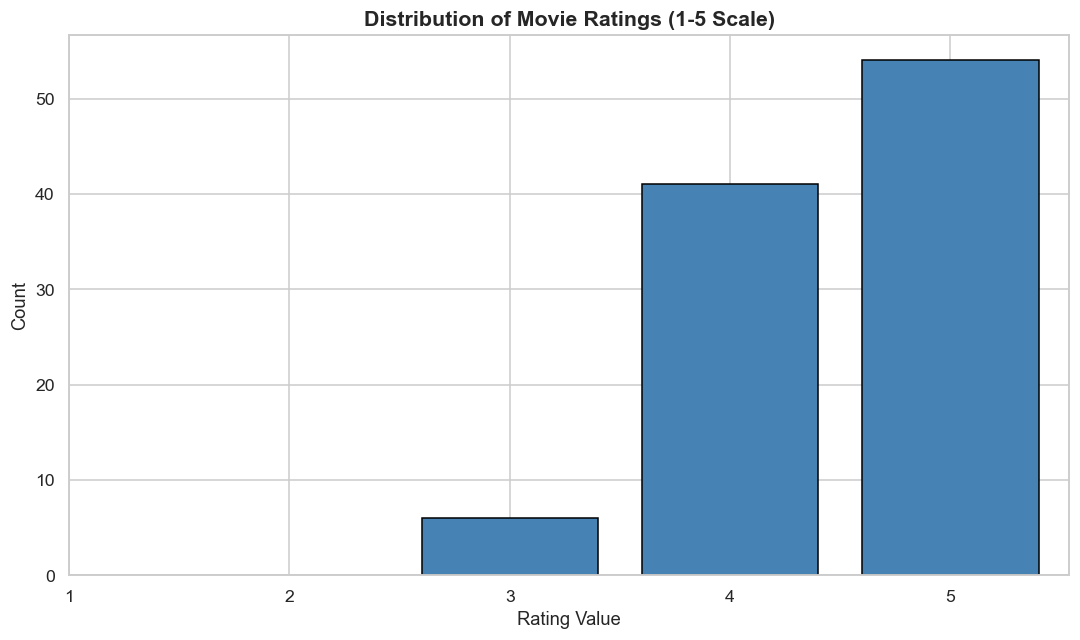

In [47]:
# rating distribution query
df_ratings = run_query("""
MATCH (:User)-[r:RATED]->(:Movie)
RETURN r.rating AS rating, count(*) AS cnt
ORDER BY rating;
""")

display(df_ratings)

# Resolve columns: empty Neo4j results often yield a DataFrame with zero columns → KeyError
def _resolve_rating_cols(df):
    if df is None or df.empty:
        return None, None
    lower = {str(c).lower(): c for c in df.columns}
    rcol = lower.get("rating") or ("rating" if "rating" in df.columns else None)
    ccol = lower.get("cnt") or ("cnt" if "cnt" in df.columns else None)
    if rcol is None or ccol is None:
        if len(df.columns) >= 2:
            return df.columns[0], df.columns[1]
    return rcol, ccol

rating_col, cnt_col = _resolve_rating_cols(df_ratings)

if rating_col is None or cnt_col is None:
    print(
        "No rating histogram: query returned no rows (empty DataFrame has no columns). "
        "Run the graph data load / MERGE cells above, then re-run this cell."
    )
elif df_ratings.empty:
    print("Rating count query returned no groups (unexpected if RATED edges exist).")
else:
    # Visualize distribution
    plt.figure(figsize=(10, 6))
    plt.bar(df_ratings[rating_col], df_ratings[cnt_col], color='steelblue', edgecolor='black')
    plt.xlabel('Rating Value', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.title('Distribution of Movie Ratings (1-5 Scale)', fontsize=14, fontweight='bold')
    plt.xticks([1, 2, 3, 4, 5])
    plt.tight_layout()
    plt.show()

**Figure 2.4.** Distribution of explicit ratings on `RATED` edges. The concentration at 4–5 stars illustrates **selection / positivity bias**, which weakens the discriminative power of raw star values for user–user similarity and motivates hybrid scoring (genre/director) and embedding-based similarity later in the notebook.

### 2.5 Genres: movie count and average user rating per genre (sorted by average rating)

The genre results show both **preference patterns** and **coverage imbalance**. On average rating alone, **Action** and **Mystery** are the highest (both **4.67**), followed closely by **Crime (4.59)** and **Sci‑Fi (4.57)**. This suggests that these genres align well with user tastes in this dataset and can serve as useful **content-based signals** for boosting recommendations (e.g., users who rated Action/Sci‑Fi highly are plausible candidates for other Action/Sci‑Fi titles).

However, the reliability of a genre signal depends strongly on **how much data supports it**:
- **Drama** dominates the catalog with **14 movies** and **57 total ratings**, making it the most statistically stable genre signal—but its average (**4.44**) also reflects the overall “inflated” rating environment.
- **Sci‑Fi** has strong coverage (**8 movies**, **35 ratings**) and a high average (**4.57**), so it is likely a robust genre for content-based boosting.
- In contrast, genres like **Mystery** (only **2 movies**, **6 ratings**) and all **single‑movie genres** (e.g., Animation, Fantasy, Music, Adventure, Horror) are “small‑n” signals: a high average could be driven by one well-liked title rather than a true broad preference for the genre.

Finally, comparing **avgRating** with **totalRatings** hints at engagement: genres can be highly rated but lightly rated (niche/long‑tail) or heavily rated but only moderately higher than others (mainstream). For recommendation quality, this motivates using genre overlap as a feature, but weighting it by **coverage** (movieCount/totalRatings) and combining it with other signals (collaborative similarity, director affinity) instead of relying on genre averages alone.

In [48]:
df = run_query(""" 
MATCH (m:Movie)-[:IN_GENRE]->(g:Genre)
MATCH (u:User)-[r:RATED]->(m)
WITH g.name AS genre, count(DISTINCT m) AS movieCount, avg(r.rating) AS avgRating,count(r) AS totalRatings
RETURN genre, movieCount, totalRatings,round(avgRating, 2) AS avgRating
ORDER BY avgRating DESC;
""" )
display(df)

,genre,movieCount,totalRatings,avgRating
0,Action,4,18,4.67
1,Mystery,2,6,4.67
2,Crime,4,22,4.59
3,Sci-Fi,8,35,4.57
4,Animation,1,4,4.50
5,Fantasy,1,4,4.50
6,Romance,3,12,4.50
7,Thriller,4,16,4.44
8,Drama,14,57,4.44
9,Comedy,3,10,4.40


### 2.6 Top 10 directors by number of movies; average user rating per director

The director distribution is **highly sparse**: out of 25 movies there are **21 directors**, so most directors appear only once. In the top‑10 list, only a few directors have multiple films—**Christopher Nolan** leads with **3 movies** (avg user rating **4.73**), while **Denis Villeneuve** and **Damien Chazelle** each have **2 movies** (avg **4.67** and **4.43**, respectively). Everyone else in the table has **movieCount = 1**, meaning their “average” reflects a single title.

This matters because director affinity is only a reliable content signal when there is **repeated evidence**. For directors with multiple movies (especially Nolan), we can be more confident using “director similarity” or “director boost” in hybrid recommendations, since the signal aggregates across several films and multiple user ratings. In contrast, a director with one film can look very strong (e.g., **Sidney Lumet: 4.80**) simply because that one movie is well-liked; this is a classic small‑sample effect and can lead to overconfident recommendations if we treat all directors equally.

**Implications for recommendation quality:** director can be a valuable hybrid feature, but it should be **confidence‑weighted** by `movieCount` (and ideally by total ratings). Strong boosts make sense for multi‑film directors; for one‑film directors we should apply lighter/regularized boosts and rely more on genres and collaborative signals.

In [49]:
df = run_query(""" 
MATCH (d:Director)<-[:DIRECTED_BY]-(m:Movie)<-[r:RATED]-(u:User)
WITH d.name AS director, count(DISTINCT m) AS movieCount, avg(r.rating) AS avgUserRating
RETURN director, movieCount, round(avgUserRating, 2) AS avgUserRating
ORDER BY movieCount DESC, avgUserRating DESC
LIMIT 10;
""" )
display(df)

,director,movieCount,avgUserRating
0,Christopher Nolan,3,4.73
1,Denis Villeneuve,2,4.67
2,Damien Chazelle,2,4.43
3,Sidney Lumet,1,4.80
4,Francis Ford Coppola,1,4.67
5,Rian Johnson,1,4.67
6,Park Chan-wook,1,4.67
7,Bong Joon-ho,1,4.67
8,Wachowski Sisters,1,4.67
9,Barry Jenkins,1,4.67


### 2.7 Per-user rating count: mean, median, standard deviation

User activity is **very uniform** in this dataset. The mean ratings per user is **5.05** and the median is **5.00**, with a very small standard deviation (**0.22**) and a narrow range (**min = 5**, **max = 6**). This indicates there are essentially **no power users** driving the interaction graph; almost everyone contributes the same number of ratings.

While this is good from a bias perspective (no single user dominates similarity), it still implies **sparsity**: with **25 movies** total, a typical user has rated only about **~20% of the catalog** (≈5/25). As a result, many user pairs will share few co-rated items, so **user–user similarity** can be noisy and recommendations may have limited coverage when using collaborative filtering alone.

**Implication for the recommender:** because all users are similarly sparse, we should expect hybrid methods (collaborative similarity + genre/director overlap) to be more stable than relying purely on overlap-based similarity, especially when generating top‑K recommendations for multiple users.

Per-user rating count — summary statistics
Mean ratings per user: 5.05
Median ratings per user: 5.00
Standard deviation: 0.22

Min: 5
Max: 6


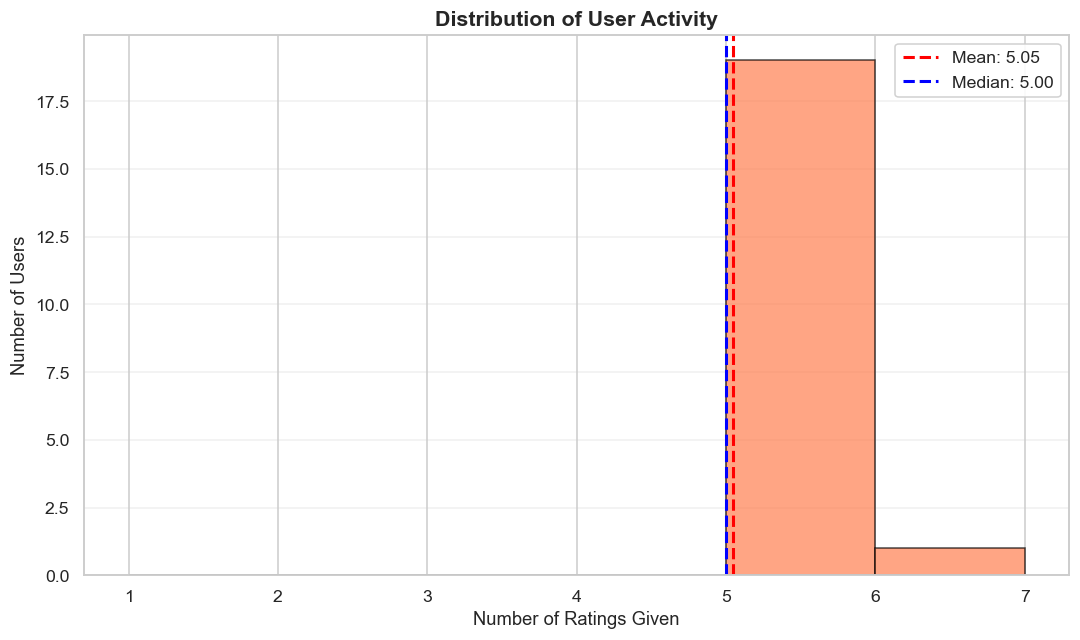

In [50]:
# Per-user rating counts (single source of truth)
user_activity = run_query("""
MATCH (u:User)-[r:RATED]->()
RETURN u.userId AS userId, count(r) AS ratingsGiven
ORDER BY ratingsGiven DESC
""")

# Compute summary statistics (pandas)
mean_ratings = user_activity["ratingsGiven"].mean()
median_ratings = user_activity["ratingsGiven"].median()
std_ratings = user_activity["ratingsGiven"].std()
min_ratings = user_activity["ratingsGiven"].min()
max_ratings = user_activity["ratingsGiven"].max()

print("Per-user rating count — summary statistics")
print(f"Mean ratings per user: {mean_ratings:.2f}")
print(f"Median ratings per user: {median_ratings:.2f}")
print(f"Standard deviation: {std_ratings:.2f}")
print(f"\nMin: {min_ratings}")
print(f"Max: {max_ratings}")

# Visualize distribution
plt.figure(figsize=(10, 6))
plt.hist(user_activity['ratingsGiven'], bins=range(1, user_activity['ratingsGiven'].max() + 2), 
         color='coral', edgecolor='black', alpha=0.7)
plt.axvline(mean_ratings, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_ratings:.2f}')
plt.axvline(median_ratings, color='blue', linestyle='--', linewidth=2, label=f'Median: {median_ratings:.2f}')
plt.xlabel('Number of Ratings Given', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)
plt.title('Distribution of User Activity', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Figure 2.7.** Histogram of per-user rating counts with mean and median reference lines. Uniform activity (narrow spread) implies **no “power users”** but also **persistent sparsity** relative to catalog size—consistent with needing content-side signals or graph embeddings when pure overlap is thin.

### 2.8 Top 5 “polarising” movies (≥3 ratings, highest rating std dev)

The most polarising movies are those with the **highest standard deviation** of ratings (with at least 3 ratings). In our results, **Whiplash** is the most polarising (std dev **1.15** with 3 ratings), followed by **The Revenant** (**1.00**, 3 ratings) and **Roma** (**0.82**, 4 ratings). Even relatively popular titles like **Pulp Fiction** (7 ratings) show meaningful disagreement (**0.69**).

Polarising movies are challenging for collaborative filtering because **overlap does not imply agreement**. Two users can both rate the same movie but have opposite opinions (one gives 5, another gives 3 or lower). Unweighted overlap-based similarity (e.g., Jaccard) treats “both rated the movie” as evidence of similarity regardless of whether their ratings match, which can introduce noise into user–user similarity and lead to recommendations that are less reliable.

**Implication for recommendations:** highly polarising titles should be treated cautiously in similarity-driven recommendation logic. In later stages we can mitigate their effect by (a) preferring weighted similarity methods (FastRP + kNN/cosine) that incorporate rating magnitude, and/or (b) down-weighting polarising items when computing similarity and leaning more on content-based signals (genre/director) to match users with the most appropriate niche preferences.

In [51]:
df = run_query(""" 
MATCH (m:Movie)<-[r:RATED]-(u:User)
WITH m, collect(r.rating) AS ratings
WHERE size(ratings) >= 3
UNWIND ratings AS rating
WITH m, rating
WITH m, count(rating) AS numRatings, stDev(rating) AS ratingStdDev
RETURN m.title AS title, numRatings, round(ratingStdDev, 2) AS ratingStdDev
ORDER BY ratingStdDev DESC
LIMIT 5;
""" )

display(df)

,title,numRatings,ratingStdDev
0,Whiplash,3,1.15
1,The Revenant,3,1.00
2,Roma,4,0.82
3,Pulp Fiction,7,0.69
4,Spirited Away,4,0.58


---
## 3. Deeper analytical questions

### Grading / submission note (Task 3)

**Questions 3.2 and 3.3** in this section are the ones intended for grading: they require **Cypher query logic**, **interpretation**, and explicit ties to **recommender implications**.

Each subsection below maps to analytic requirements: **(a)** taste overlap, **(b)** cold start, **(c)** diversity vs popularity, **(d)** genre/director signals.

### 3.1 Taste Overlap Without Algorithms

**Query logic**:

- Match triples (u1)-[r1:RATED]->(m)<-[r2:RATED]-(u2) so that each movie m is co-rated by users u1 and u2.
- Use WHERE u1.userId < u2.userId to avoid counting each pair twice and to avoid self-pairs.
- For each user pair, count how many movies they both rated (overlapCount) and compute the average absolute rating difference on those shared movies (avgAbsDiff).
- Sort primarily by overlapCount (descending) and secondarily by avgAbsDiff (ascending), then take the top 10 pairs.


In [52]:
df = run_query("""
MATCH (u1:User)-[r1:RATED]->(m:Movie)<-[r2:RATED]-(u2:User)
WHERE u1.userId < u2.userId
WITH u1, u2,
     count(m) AS overlapCount,
     avg(abs(r1.rating - r2.rating)) AS avgAbsDiff
RETURN u1.name AS user1,
       u2.name AS user2,
       overlapCount,
       round(avgAbsDiff, 2) AS avgAbsDiff
ORDER BY overlapCount DESC, avgAbsDiff ASC
LIMIT 10;
""")
display(df)

,user1,user2,overlapCount,avgAbsDiff
0,Grace Liu,Tom Anderson,5,0.40
1,Karen Singh,Quinn Zhang,5,0.60
2,Grace Liu,Paul Garcia,5,0.60
3,Paul Garcia,Tom Anderson,5,0.60
4,Henry Park,Ryan Murphy,5,0.60
5,Bob Martinez,David Kim,5,0.80
6,Noah Williams,Ryan Murphy,5,1.00
7,Henry Park,Noah Williams,5,1.20
8,Maya Patel,Quinn Zhang,4,0.00
9,Alice Chen,Quinn Zhang,4,0.25


**Interpretation**

This analysis identifies pairs of users who have rated the same movies and measures two things:  
- **overlapCount** = how many movies they both rated (co-engagement), and  
- **avgAbsDiff** = how similarly they rated those shared movies (taste agreement; lower is more similar).

Even among the top-overlap pairs (mostly **5 shared movies**), agreement varies substantially. For example, **Grace Liu and Tom Anderson** have overlapCount **5** with a low avgAbsDiff of **0.40**, suggesting they not only watch similar movies but also evaluate them similarly. In contrast, **Henry Park and Noah Williams** also share **5** movies but have a much larger avgAbsDiff (**1.20**), meaning they often disagree despite high overlap. This directly shows that **high overlap does not necessarily imply similar taste**.

We also see that lower overlap can still indicate strong similarity: **Maya Patel and Quinn Zhang** share **4** movies and have avgAbsDiff **0.00**, indicating near-identical ratings on the items they both rated.

**Conclusion:** overlapCount is useful for finding candidate “neighbors,” but it is incomplete on its own. A rating-aware measure (like avgAbsDiff here, cosine similarity on rating vectors, or embedding-based cosine similarity via FastRP + kNN) better captures true taste similarity and helps avoid recommending items from users who merely share viewing history rather than genuine preference alignment.

### 3.2 Genre Preference Profiles

**Query logic**:

- For each `(User)-[:RATED]->(Movie)-[:IN_GENRE]->(Genre)` triple, group by user and genre and compute the **average rating** the user gives to movies in that genre; this forms each user’s genre preference profile.
- Collect these per-genre averages into a vector for each user (one dimension per genre the user has rated).
- For Alice Chen (the target user), build her genre rating vector and, for every other user, build a corresponding vector over the same genre space.
- Compute **cosine similarity** between Alice’s vector and each other user’s vector: a value close to 1 means very similar genre preferences (same pattern of likes/dislikes across genres), while values near 0 indicate weak or no alignment.
- Return the three users with the highest cosine similarity to Alice as the users whose genre profiles are most similar to hers.

In [53]:
# Per-user genre preference profile: avg rating per genre
df_genre_profiles = run_query("""
MATCH (u:User)-[r:RATED]->(m:Movie)-[:IN_GENRE]->(g:Genre)
WITH u, g.name AS genre, avg(r.rating) AS avgRating
RETURN u.name AS user,
       genre,
       round(avgRating, 2) AS avgRating
ORDER BY user, avgRating desc;
""")
display(df_genre_profiles)

,user,genre,avgRating
0,Alice Chen,Crime,5.00
1,Alice Chen,Thriller,5.00
2,Alice Chen,Action,4.67
3,Alice Chen,Sci-Fi,4.60
4,Alice Chen,Drama,4.50
...,...,...,...
97,Sara Hassan,Romance,4.00
98,Tom Anderson,Crime,5.00
99,Tom Anderson,Action,4.75
100,Tom Anderson,Sci-Fi,4.50


In [54]:
TARGET_USER = "Alice Chen"

df_similar_to_alice = run_query("""
WITH $targetName AS targetName

// Target user genre profile
MATCH (u:User {name: targetName})-[r:RATED]->(m:Movie)-[:IN_GENRE]->(g:Genre)
WITH u, g.name AS genre, avg(r.rating) AS avgRating
WITH u, collect({genre: genre, rating: avgRating}) AS targetProfile

// All other users and their genre profiles
MATCH (other:User)
WHERE other <> u
CALL {
  WITH other
  MATCH (other)-[r2:RATED]->(m2:Movie)-[:IN_GENRE]->(g2:Genre)
  WITH g2.name AS genre, avg(r2.rating) AS avgRating
  RETURN collect({genre: genre, rating: avgRating}) AS otherProfile
}

// Compute cosine similarity between targetProfile and otherProfile
WITH u, targetProfile, other, otherProfile,
     [x IN targetProfile | x.genre] AS targetGenres
WITH u, other, targetProfile, otherProfile,
     [g IN targetGenres WHERE any(o IN otherProfile WHERE o.genre = g)] AS sharedGenres

// dot product over shared genres
WITH u, other, sharedGenres,
     reduce(dot = 0.0, g IN sharedGenres |
           dot + (
             [x IN targetProfile WHERE x.genre = g][0].rating *
             [y IN otherProfile WHERE y.genre = g][0].rating
           )
     ) AS dotProduct,
     // norms over all genres each user has ratings for
     reduce(tNormSq = 0.0, x IN targetProfile | tNormSq + x.rating^2) AS targetNormSq,
     reduce(oNormSq = 0.0, y IN otherProfile | oNormSq + y.rating^2) AS otherNormSq

WITH other,
     dotProduct,
     sqrt(targetNormSq) AS targetNorm,
     sqrt(otherNormSq) AS otherNorm

WITH other,
     CASE
       WHEN targetNorm = 0 OR otherNorm = 0 THEN 0.0
       ELSE dotProduct / (targetNorm * otherNorm)
     END AS cosineSim

RETURN other.name AS user,
       round(cosineSim, 3) AS cosineSimilarity
ORDER BY cosineSimilarity DESC
LIMIT 3;
""", {"targetName": TARGET_USER})

display(df_similar_to_alice)

Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is deprecated. Use CALL (other) { ... }', position=<SummaryInputPosition line=12, column=1, offset=341>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 341, 'line': 12, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\nWITH $targetName AS targetName\n\n// Target user genre profile\nMATCH (u:User {name: targetName})-[r:RATED]->(m:Movie)-[:IN_GENRE]->(g:Genre)\nWITH u, g.name AS genre, avg(r.rating) AS avgRating\nWITH u, collect({genre: genre, rating: avgRating}) AS targetProfile\n\n// All other users and their genre profiles\nMATCH (other:User)\nWH

,user,cosineSimilarity
0,Grace Liu,0.906
1,Paul Garcia,0.903
2,Tom Anderson,0.902


**Interpretation**

We first computed each user’s **genre preference profile**: the average rating they give to movies in each genre. For Alice Chen, for example, Crime and Thriller sit at the top of her profile (both ≈5.0), followed by Action (≈4.67), Sci‑Fi (≈4.60), and Drama (≈4.50). This shows Alice strongly favors Crime/Thriller and generally likes high‑intensity genres (Action/Sci‑Fi) while still being positive on Drama.

To compare other users to Alice, we treated these per‑genre averages as a **rating vector** and used **cosine similarity** over shared genres. The top three users by cosine similarity to Alice are:

- **Grace Liu** (cosineSimilarity ≈ **0.906**)
- **Paul Garcia** (≈ **0.903**)
- **Tom Anderson** (≈ **0.902**)

These high cosine scores mean that, across all genres they share with Alice, these users have **very similar patterns of preference**: they tend to like and dislike the same genres to similar degrees, not just share a single favorite. For instance, Tom Anderson also gives very high ratings to Crime and reasonably high ratings to Action/Sci‑Fi, mirroring Alice’s multi‑genre profile.

From a recommender‑system perspective, genre‑level profiles provide a **content-based view of similarity** that complements raw co‑ratings. They are especially useful in a sparse setting like this one: even when two users have few movies in common, we can still infer taste alignment from how they rate **genres**. Combined with collaborative filtering (e.g., Jaccard or FastRP + kNN on user–movie ratings), genre‑profile similarity helps target recommendations toward movies that match a user’s expressed genre tastes rather than relying solely on noisy overlap at the individual-title level.

### 3.3 Long-tail analysis

**Tables 3.3a–b** (next cell) summarize head-movie concentration and candidate “hidden gems.” **Figure 3.3** plots the cumulative share of all ratings by movie popularity rank (Pareto view).

**Query logic (Top-3 concentration)**

- Match all `(:User)-[r:RATED]->(:Movie)` relationships and group by movie to compute `numRatings = count(r)`.
- Sort movies by `numRatings DESC` and take the top 3 most-rated movies.
- Compute each top movie’s share of all ratings as `pctOfAllRatings = 100 * numRatings / totalRatings` (where `totalRatings` is the total number of `RATED` relationships in the dataset).

**Query logic (Hidden gems)**

- First compute the bottom-quartile threshold `q1` for rating counts across movies using `percentileCont(numRatings, 0.25)`.
- Then recompute, for each movie, both `numRatings = count(r)` and `avgRating = avg(r.rating)`.
- Filter to movies with `numRatings <= q1` (few ratings) and `avgRating >= 4.0` (high average rating). These are “hidden gems”: well-liked by the few users who rated them, but low-attention items in the long tail.


,title,numRatings,pctOfAllRatings
0,Pulp Fiction,7,6.93
1,Inception,7,6.93
2,The Godfather,6,5.94


,title,numRatings,avgRating
0,Moonlight,3,4.67
1,Parasite,3,4.67
2,Oldboy,3,4.67
3,Knives Out,3,4.67
4,Everything Everywhere All at Once,3,4.33
5,Whiplash,3,4.33
6,Her,3,4.33
7,Mad Max: Fury Road,3,4.33
8,The Revenant,3,4.00
9,The Dark Knight,4,5.00


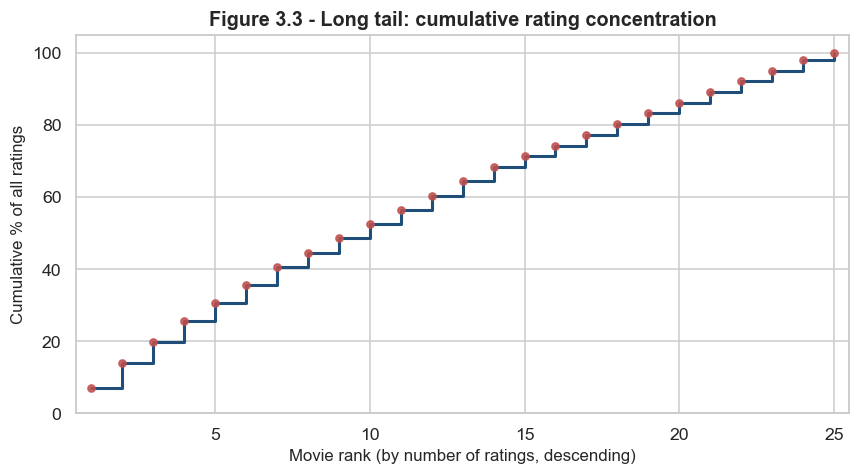

In [56]:
# Rating count per movie and share of total for the top 3 most-rated movies
df_top3 = run_query("""
MATCH (m:Movie)<-[r:RATED]-(:User)
WITH m, count(r) AS numRatings
ORDER BY numRatings DESC
WITH collect({title: m.title, numRatings: numRatings}) AS movies,
     sum(numRatings) AS totalRatings
WITH movies[0..3] AS top3, totalRatings
UNWIND top3 AS m
RETURN m.title AS title,
       m.numRatings AS numRatings,
       round(100.0 * m.numRatings / totalRatings, 2) AS pctOfAllRatings
ORDER BY numRatings DESC;
""")
display(df_top3)

df_hidden_gems = run_query("""
CALL () {
  // Compute the 25th percentile of rating counts across all movies
  MATCH (m:Movie)<-[r:RATED]-(:User)
  WITH count(r) AS numRatings
  RETURN percentileCont(numRatings, 0.25) AS q1
}

MATCH (m:Movie)<-[r:RATED]-(:User)
WITH m, count(r) AS numRatings, avg(r.rating) AS avgRating, q1
WHERE numRatings <= q1 AND avgRating >= 4.0

RETURN m.title AS title,
       numRatings,
       round(avgRating, 2) AS avgRating
ORDER BY numRatings ASC, avgRating DESC
LIMIT 10;
""")
display(df_hidden_gems)

# Figure 3.3 — cumulative rating concentration (long-tail / Pareto view)
df_rank = run_query("""
MATCH (m:Movie)<-[r:RATED]-(:User)
RETURN m.title AS title, count(r) AS numRatings
ORDER BY numRatings DESC
""")
df_rank = df_rank.sort_values("numRatings", ascending=False).reset_index(drop=True)
total_r = df_rank["numRatings"].sum()
df_rank["rank"] = range(1, len(df_rank) + 1)
df_rank["cum_pct_ratings"] = 100.0 * df_rank["numRatings"].cumsum() / total_r

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.step(df_rank["rank"], df_rank["cum_pct_ratings"], where="post", color="#1f4e79", linewidth=2)
ax.scatter(df_rank["rank"], df_rank["cum_pct_ratings"], color="#c0504d", s=22, zorder=3, alpha=0.85)
ax.set_xlabel("Movie rank (by number of ratings, descending)")
ax.set_ylabel("Cumulative % of all ratings")
ax.set_title("Figure 3.3 - Long tail: cumulative rating concentration")
ax.set_ylim(0, 105)
ax.set_xlim(0.5, len(df_rank) + 0.5)
plt.tight_layout()
plt.show()

**Figure 3.3.** Step curve of **cumulative share of ratings** vs **movie popularity rank**. Even in this small catalog, a few titles absorb a disproportionate share of interactions motivating hybrid and content-based promotion of long-tail items.

**Interpretation – popularity concentration and sparsity**

The **two** most‑rated movies are **Inception** and **Pulp Fiction** (7 ratings each). Several films tie at **6** ratings, including **The Godfather** and **The Matrix** (see §2.3). The long‑tail query’s **top‑three rows** (sorted by count, then title) are **Pulp Fiction**, **Inception**, and **The Godfather**; those three sums to **20** of **101** ratings, i.e. **≈19.8%** (≈6.93% + 6.93% + 5.94% per row in the table above). In absolute terms even these “head” items have very few interactions. This confirms that the dataset is **extremely sparse**: no movie has more than 7 ratings, and many titles are only a few ratings behind the leaders. Collaborative filtering will naturally rely more on these slightly more‑rated items, but there is not a sharp gap between head and tail—almost everything is low‑count.

**Hidden gems and the long tail**

The “hidden gems” query shows several movies with **few ratings but high averages**, e.g.:

- **Moonlight, Parasite, Knives Out, Oldboy** (each **3 ratings**, avgRating ≈ **4.67**)
- **Mad Max: Fury Road, Everything Everywhere All at Once, Whiplash, Her** (3 ratings, avgRating ≈ **4.33**)
- **The Revenant** (3 ratings, avgRating **4.00**)
- **The Dark Knight** (4 ratings, avgRating **5.00**)

These are prime **long‑tail items**: they are strongly liked by the small number of users who rated them, but they receive much less attention than the top‑rated movies by count. Because they have so few interactions, standard collaborative filtering struggles to find reliable neighbours or co‑occurrence patterns for them, so they are often **under‑recommended** despite their quality.

**Why the long tail is hard, and how to surface long‑tail items in a graph-based recommender**

Long‑tail movies are hard to recommend because collaborative filtering depends on **overlap and frequency**: with only 3–4 ratings, a movie has weak statistical signal, and user–user or item–item similarity becomes noisy. A popularity‑driven system will keep reinforcing head items like Inception and Pulp Fiction, pushing hidden gems further down.

In a graph‑based setting, we can mitigate this by:

- **Using rating strength, not just count:** Treat high ratings (e.g. ≥ 4) as strong edges even when counts are low, so a few very positive ratings still matter.
- **Leveraging content structure:** Connect long‑tail movies to popular ones through shared **genres** and **directors** (`IN_GENRE`, `DIRECTED_BY` relationships), so users who like certain genres or auteurs are exposed to them even if direct co‑rating overlap is small.
- **Allocating exploration budget:** Reserve a portion of recommendation slots for **exploration**, prioritising high‑rated but low‑count movies that are close in the graph (shared genre/director) to items the user already enjoys.

These strategies help a graph-based recommender surface high‑quality long‑tail items while still respecting collaborative signals, rather than relying purely on popularity.

### 3.4 Director and Genre Co-Occurrence

**Query logic (director–genre co-occurrence)**

- Traverse the enriched graph along `(d:Director)<-[:DIRECTED_BY]-(m:Movie)-[:IN_GENRE]->(g:Genre)` to see which genres each director works in.
- For each `(director, genre)` pair, group all movies that connect them and compute:
  - `movieCount = count(DISTINCT m)` — how many movies this director has in that genre.
  - `avgRating = avg(r.rating)` — the average user rating across those movies, using `(:User)-[r:RATED]->(m)` relationships.
- Return one row per `(director, genre)` with `movieCount` and `avgRating`, ordered by `movieCount` (and then `avgRating`) to highlight the strongest director–genre associations.

**Query logic (crossover directors and their genre distributions)**

- First, find **crossover directors**: match `(d:Director)<-[:DIRECTED_BY]-(m:Movie)-[:IN_GENRE]->(g:Genre)`, collect the distinct genres per director, and keep only those with `size(genres) >= 2` (directors who appear in at least two different genres).
- Then, for this filtered set of directors, re-match `(d)<-[:DIRECTED_BY]-(m:Movie)-[:IN_GENRE]->(g:Genre)` and join to user ratings `(:User)-[r:RATED]->(m)`.
- Group by `(director, genre)` and compute:
  - `movieCount = count(DISTINCT m)` per genre,
  - `avgRating = avg(r.rating)` per genre.
- Return one row per crossover director and genre, ordered by director and `movieCount`, to show each crossover director’s **genre distribution** and how well their movies are received in each genre.

In [57]:
df_dir_genre = run_query("""
MATCH (d:Director)<-[:DIRECTED_BY]-(m:Movie)-[:IN_GENRE]->(g:Genre)
MATCH (:User)-[r:RATED]->(m)
WITH d, g, count(DISTINCT m) AS movieCount, avg(r.rating) AS avgRating
RETURN d.name AS director,
       g.name AS genre,
       movieCount,
       round(avgRating, 2) AS avgRating
ORDER BY director, movieCount DESC, genre;
""")
display(df_dir_genre)

,director,genre,movieCount,avgRating
0,Alejandro G. Iñárritu,Adventure,1,4.00
1,Alejandro G. Iñárritu,Drama,1,4.00
2,Alfonso Cuarón,Biography,1,4.00
3,Alfonso Cuarón,Drama,1,4.00
4,Barry Jenkins,Biography,1,4.67
5,Barry Jenkins,Drama,1,4.67
6,Bong Joon-ho,Drama,1,4.67
7,Bong Joon-ho,Thriller,1,4.67
8,Christopher Nolan,Sci-Fi,2,4.64
9,Christopher Nolan,Action,1,5.00


In [58]:
df_crossover = run_query("""
MATCH (d:Director)<-[:DIRECTED_BY]-(m:Movie)-[:IN_GENRE]->(g:Genre)
WITH d, collect(DISTINCT g.name) AS genres
WHERE size(genres) >= 2    // crossover directors only

// Recompute per-genre stats for those directors
MATCH (d)<-[:DIRECTED_BY]-(m:Movie)-[:IN_GENRE]->(g:Genre)
MATCH (:User)-[r:RATED]->(m)
WITH d, g.name AS genre, count(DISTINCT m) AS movieCount, avg(r.rating) AS avgRating
RETURN d.name AS director,
       genre,
       movieCount,
       round(avgRating, 2) AS avgRating
ORDER BY director, movieCount DESC, genre;
""")
display(df_crossover)

,director,genre,movieCount,avgRating
0,Alejandro G. Iñárritu,Adventure,1,4.00
1,Alejandro G. Iñárritu,Drama,1,4.00
2,Alfonso Cuarón,Biography,1,4.00
3,Alfonso Cuarón,Drama,1,4.00
4,Barry Jenkins,Biography,1,4.67
5,Barry Jenkins,Drama,1,4.67
6,Bong Joon-ho,Drama,1,4.67
7,Bong Joon-ho,Thriller,1,4.67
8,Christopher Nolan,Sci-Fi,2,4.64
9,Christopher Nolan,Action,1,5.00


**Interpretation – director–genre relationships and crossover directors**

By traversing `(Director)<-[:DIRECTED_BY]-(Movie)-[:IN_GENRE]->(Genre)` and aggregating ratings, we see which genres each director works in and how those films are received. A few patterns stand out:

- Some directors are **strongly associated with a single genre cluster**, for example:
  - **Christopher Nolan** has multiple Sci‑Fi titles (movieCount = 2, avgRating ≈ 4.64) and also very highly rated entries in **Action** and **Crime** (avgRating = 5.00 in both), with solid scores in **Drama** and **Thriller**. This makes him a strong signal for high‑intensity, genre‑blended films.
  - **Denis Villeneuve** appears in **Sci‑Fi** (movieCount = 2, avgRating ≈ 4.67) and also in **Action** and **Drama** with high averages (≈4.60–4.75), again tying him to visually ambitious, serious genre work.
  - **Damien Chazelle** spreads across **Drama**, **Music**, and **Romance** with good but slightly lower averages (4.33–4.50), reflecting a focus on character‑ and music‑driven stories.

- Many directors show up as **crossover directors**, with movies tagged in at least two genres:
  - **Bong Joon‑ho** spans **Drama** and **Thriller** (both ≈4.67).
  - **Céline Sciamma** spans **Drama** and **Romance** (≈4.60).
  - **Daniels** covers **Comedy** and **Sci‑Fi** (≈4.33).
  - **Hayao Miyazaki** appears in both **Animation** and **Fantasy** (≈4.50).
  - Several others (e.g., **Francis Ford Coppola**, **David Fincher**, **Wes Anderson**) split their films between Drama and a second genre (Crime, Biography, Comedy, etc.).

These patterns suggest that **director–genre co-occurrence encodes useful content structure**: some directors “anchor” particular genre combinations (Nolan: Sci‑Fi/Action/Crime; Villeneuve: Sci‑Fi/Drama/Action; Miyazaki: Animation/Fantasy), while others explore different tonal or stylistic spaces across genres.

**Implications for a hybrid recommender**

In a hybrid graph-based recommender, we can leverage these relationships in several ways:

- When a user rates multiple films by a director highly (e.g., Nolan or Villeneuve), we can **boost other films by that director**, especially in the same genres (Sci‑Fi/Action/Crime), because both the director and genre signals are strong.
- For crossover directors, we can use their **genre distribution** to avoid over-generalising: if a user loves Bong Joon‑ho’s Thriller work, we should primarily boost his Thriller/Drama titles, not treat “Bong Joon‑ho” as a flat label across all possible genres.
- When collaborative filtering is sparse (few co-ratings), director–genre co-occurrence provides an additional path in the graph: users → movies → director/genre → other movies, enabling us to recommend thematically and stylistically similar content even without strong user–user overlap.

Overall, director–genre relationships offer a rich, interpretable content-based signal that complements user similarity. They help explain **why** certain recommendations make sense (“you liked Nolan’s Sci‑Fi/Action films; here’s another high‑rated Sci‑Fi/Action movie by him or a similar director”), and they are especially valuable for **long-tail and crossover** items that lack strong collaborative evidence but sit in well-understood director–genre niches.

---
## 4. GDS: projections and similarity


### GDS 1: User similarity via Node Similarity (Jaccard)

**Graph projection**

- We **drop** any existing in-memory graph named `user_movie_unweighted` (with `failIfMissing: false` so no error is thrown if it doesn't exist) before creating a new one.
- We **build** an in-memory graph named `user_movie_unweighted` with nodes from labels **User** and **Movie** and relationships of type **RATED**, using **undirected** orientation so that user–movie links are treated as symmetric  (“neighbours of user” = movies they rated, and “neighbours of movie” = users who rated it). 
- No relationship properties are loaded, so the graph is **unweighted** and suitable for Jaccard.
- The result is a **bipartite** projection: 
    - 45 nodes (20 users + 25 movies) and 
    - 202 relationships (101 RATED edges stored in both directions). 
- This graph is the input for Node Similarity: we compare **User** nodes based on their shared **Movie** neighbours (co-rated movies); similarity is computed from overlap of rated movies, not from rating values.


### User Similarity via Node Similarity

In [59]:
# Create or replace a GDS projection of the User–Movie ratings graph (unweighted)
run_query("""
CALL gds.graph.drop('user_movie_unweighted', false) YIELD graphName
RETURN graphName
""")  

df_proj = run_query("""
CALL gds.graph.project(
  'user_movie_unweighted',
  ['User', 'Movie'],
  {
    RATED: {
      type: 'RATED',
      orientation: 'UNDIRECTED'
    }
  }
)
YIELD graphName, nodeCount, relationshipCount
""")
display(df_proj)



,graphName,nodeCount,relationshipCount
0,user_movie_unweighted,45,202


**Node Similarity stream (Jaccard)**

- We use **Node Similarity** with **Jaccard** to measure user–user similarity from co-rated movies (set overlap) without using rating values, as the assignment’s baseline before weighted similarity in the next task. Run it in **stream** mode on the projected graph using **filtered** procedures so we can restrict which nodes are compared.
- Set **sourceNodeFilter** and **targetNodeFilter** to `'User'` so that only **User–User** pairs are compared; similarity is computed from shared **Movie** neighbours (movies both users rated).

- Use **topK: 5** to limit to the top 5 most similar users per user.


- The stream returns each user’s neighbours (other users) together with the Jaccard similarity score. 
- For Alice Chen, her top five neighbours (Maya, Quinn, Paul, Karen, and Grace) all have a similarity of **0.571**, meaning they overlap with Alice to the same degree in **which movies they rated** (same intersection and union of rated movies).
- Bob Martinez and David Kim have a Jaccard similarity of **1.0**, so they **completely overlap** in the set of movies they rated (identical rated-movie sets). 
- Note that Jaccard does not use rating values, only whether a movie was rated or not.


In [60]:
df_ns = run_query("""
CALL gds.nodeSimilarity.filtered.stream('user_movie_unweighted', {
  sourceNodeFilter: 'User',
  targetNodeFilter: 'User',
  relationshipTypes: ['RATED'],
  similarityMetric: 'JACCARD',
  topK: 5
})
YIELD node1, node2, similarity
WITH gds.util.asNode(node1) AS u1,
     gds.util.asNode(node2) AS u2,
     similarity
RETURN u1.userId AS userId1,
       u1.name   AS user1,
       u2.userId AS userId2,
       u2.name   AS user2,
       round(similarity, 3) AS jaccard
ORDER BY  user1, jaccard DESC;
""")
display(df_ns)

,userId1,user1,userId2,user2,jaccard
0,U001,Alice Chen,U013,Maya Patel,0.571
1,U001,Alice Chen,U017,Quinn Zhang,0.571
2,U001,Alice Chen,U016,Paul Garcia,0.571
3,U001,Alice Chen,U011,Karen Singh,0.571
4,U001,Alice Chen,U007,Grace Liu,0.571
5,U002,Bob Martinez,U004,David Kim,1.000
6,U002,Bob Martinez,U014,Noah Williams,0.429
7,U002,Bob Martinez,U018,Ryan Murphy,0.429
8,U002,Bob Martinez,U008,Henry Park,0.429
9,U002,Bob Martinez,U010,James Brown,0.250



**Write SIMILAR_TASTE back to the graph**

- We delete any existing **SIMILAR_TASTE** relationships so that re-running the write does not create duplicates.
- We then run `gds.nodeSimilarity.filtered.write` with `sourceNodeFilter` and `targetNodeFilter` set to `'User'`, topK: 5, writeRelationshipType: 'SIMILAR_TASTE', and writeProperty: 'score'. 
- This writes Jaccard similarity as score between User nodes for use in collaborative-filtering recommendation queries.
 - The write compares only the **20 User** nodes with **Movie** nodes  used only as bridges for computing overlap. 
 - With **topK: 5**, each user gets at most five most-similar users, so we obtain **up to 100** SIMILAR_TASTE relationships. 
 - In the results, the top 15 pairs all have a **Jaccard score of 1**, including Bob Martinez–David Kim and Grace Liu–Paul Garcia meaning those users rated exactly the same set of movies.

 **What Jaccard captures and when it falls short**

- Jaccard compares users on binary overlap: whether they rated the same movies. It does not use rating values, so it does not tell us whether both enjoyed the movies or had different tastes (e.g. one 5, the other 2).
- It is useful for finding or tracking active users who watch the same movies and for co-engagement (who shares viewing overlap), and it is simple and robust when only “rated or not” matters.
- It falls short for recommender systems because it does not capture preference overlap: two users can have the same set of rated movies but opposite tastes. 
- For “users like you also liked…”, we need rating-aware similarity (e.g. cosine or Pearson on rating vectors, or embedding-based similarity), which uses how users rated, not just which movies they rated.

In [61]:
# delete the SIMILAR_TASTE relationships to avoid duplicates
run_query(""" 
MATCH ()-[s:SIMILAR_TASTE]->()
DELETE s;
""" )

# Write SIMILAR_TASTE relationships back to the graph (filtered, same as stream)
df_write = run_query("""
CALL gds.nodeSimilarity.filtered.write('user_movie_unweighted', {
  sourceNodeFilter: 'User',
  targetNodeFilter: 'User',
  relationshipTypes: ['RATED'],
  similarityMetric: 'JACCARD',
  topK: 5,
  writeRelationshipType: 'SIMILAR_TASTE',
  writeProperty: 'score'
})
YIELD nodesCompared, relationshipsWritten
RETURN nodesCompared, relationshipsWritten;
""")
display(df_write)

,nodesCompared,relationshipsWritten
0,20,100


**Top 15 most similar user pairs (by Jaccard score)**

In [62]:

df_edges = run_query("""
MATCH (u1:User)-[s:SIMILAR_TASTE]->(u2:User)
RETURN u1.name AS user1,
       u2.name AS user2,
       round(s.score, 3) AS score
ORDER BY score DESC, user1, user2
LIMIT 15;
""")
display(df_edges)

,user1,user2,score
0,Bob Martinez,David Kim,1.0
1,David Kim,Bob Martinez,1.0
2,Grace Liu,Paul Garcia,1.0
3,Grace Liu,Tom Anderson,1.0
4,Henry Park,Noah Williams,1.0
5,Henry Park,Ryan Murphy,1.0
6,Karen Singh,Quinn Zhang,1.0
7,Noah Williams,Henry Park,1.0
8,Noah Williams,Ryan Murphy,1.0
9,Paul Garcia,Grace Liu,1.0


### GDS 2: User similarity via k-Nearest Neighbors with FastRP embeddings

**Goal:** Compute user–user similarity using **rating-weighted** structure (unlike Jaccard), then compare with GDS 1 and discuss trade-offs.

**Graph projection (weighted)**

- We create a **second** in-memory graph, `user_movie_weighted`, with the same nodes (User, Movie) and relationship type (RATED), but we **load the relationship property `rating`** so that each edge carries the user’s rating (1–5).
- The graph is still undirected and bipartite (45 nodes, 202 relationships). 
- The difference from GDS 1 is that relationships are **weighted** by `rating`, so FastRP can use “how much” a user liked a movie, not just “rated or not”.




In [63]:
# Drop if exists, then create weighted projection for FastRP
run_query("""
CALL gds.graph.drop('user_movie_weighted', false) YIELD graphName
RETURN graphName
""")

df_proj_w = run_query("""
CALL gds.graph.project(
  'user_movie_weighted',
  ['User', 'Movie'],
  {
    RATED: {
      type: 'RATED',
      orientation: 'UNDIRECTED',
      properties: ['rating']
    }
  }
)
YIELD graphName, nodeCount, relationshipCount
RETURN graphName, nodeCount, relationshipCount
""")
display(df_proj_w)

,graphName,nodeCount,relationshipCount
0,user_movie_weighted,45,202


**FastRP (embeddings)**

- We run **FastRP** in **mutate** mode on `user_movie_weighted` so that we can save the results in-memory without affecting the database.
- We then use **relationshipWeightProperty: 'rating'** so that high-rated movies contribute more to a user’s embedding than low-rated ones.
- Parameters: 
    - **embeddingDimension: 64** (balanced tradeoff between a larger vector e.g. 128 with more noise and a smaller vector e.g. 16 with less information), 
    - **iterationWeights: [0.0, 1.0, 1.0]** (first weight 0 to avoid dominating by initial randomness which usualy has more noise while later iteration compare structure differences), 
    - **randomSeed: 42** for reproducibility. 
- The algorithm wrote 45 **embedding** vectors for every node (User and Movie) in the catalog.

In [64]:
# FastRP: weighted embeddings; mutate writes 'embedding' onto nodes in the catalog

run_query("""
CALL gds.fastRP.mutate(
  'user_movie_weighted',
  {
    embeddingDimension: 64,
    randomSeed: 42,
    mutateProperty: 'embedding',
    relationshipWeightProperty: 'rating',
    iterationWeights: [0.0, 1.0, 1.0]
  }
)
YIELD nodePropertiesWritten
RETURN nodePropertiesWritten
""")

,nodePropertiesWritten
0,45


**kNN stream (cosine similarity)**

- We run **kNN** in stream mode using **nodeProperties: ['embedding']** from the FastRP vector results. 
- kNN compares nodes by **cosine similarity** of their embedding vectors, so users with similar weighted rating neighborhoods get high similarity.
- We filter to **User–User** pairs and one direction per pair with `elementId(u1) < elementId(u2)` so that we dont have duplicates e.g. Alice-Tom and Tom-Alice.
- Then take the **top 15** pairs by similarity to present the 15 most similar user pairs by cosine (embedding) similarity.
- `gds.util.asNode()` converts the projection ID's back to node properties and labels
- Pairs such as Paul–Tom, Tom–Grace, Ryan–Henry, Karen–Quinn, and Paul–Grace have cosine similarity 1.0, so their embeddings are identical in direction; the model treats them as having the same taste. 
- Sara and Frank have similarity 0.991, so they are almost as similar, with very similar taste on the movies they rated.


**Write KNN_SIMILAR**

- We delete any existing **KNN_SIMILAR** relationships, then run **kNN write** with **writeRelationshipType: 'KNN_SIMILAR'** and **writeProperty: 'score'** (and **topK: 5** per user) so that the graph stores these similarity edges for later recommendation queries.

In [65]:
# kNN stream: cosine similarity over embeddings; then filter to User-User and top 15
df_knn = run_query("""
CALL gds.knn.stream('user_movie_weighted', {
  nodeProperties: ['embedding'],
  topK: 5,
  randomSeed: 42,
  concurrency: 1
})
YIELD node1, node2, similarity
WITH gds.util.asNode(node1) AS u1, gds.util.asNode(node2) AS u2, similarity
WHERE u1:User AND u2:User AND elementId(u1) < elementId(u2)
RETURN u1.name AS user1, u2.name AS user2, round(similarity, 3) AS cosineSimilarity
ORDER BY cosineSimilarity DESC
LIMIT 15
""")
# Delete existing KNN_SIMILAR to avoid duplicates
run_query("""
MATCH ()-[r:KNN_SIMILAR]->()
DELETE r
""")

# kNN write: persist KNN_SIMILAR with score
df_knn_write = run_query("""
CALL gds.knn.write('user_movie_weighted', {
  nodeProperties: ['embedding'],
  topK: 5,
  randomSeed: 42,
  concurrency: 1,
  writeRelationshipType: 'KNN_SIMILAR',
  writeProperty: 'score'
})
YIELD nodesCompared, relationshipsWritten
RETURN nodesCompared, relationshipsWritten
""")

# Top 15 User-User pairs by KNN (cosine) score
df_knn_edges = run_query("""
MATCH (u1:User)-[k:KNN_SIMILAR]->(u2:User)
WHERE elementId(u1) < elementId(u2)
RETURN u1.name AS user1, u2.name AS user2, round(k.score, 3) AS score
ORDER BY score DESC, user1, user2
LIMIT 15
""")
display(df_knn_edges)

,user1,user2,score
0,Paul Garcia,Grace Liu,1.000
1,Paul Garcia,Tom Anderson,1.000
2,Quinn Zhang,Karen Singh,1.000
3,Ryan Murphy,Henry Park,1.000
4,Tom Anderson,Grace Liu,1.000
5,Bob Martinez,David Kim,0.999
6,Noah Williams,Henry Park,0.999
7,Noah Williams,Ryan Murphy,0.999
8,Carol White,Olivia Jones,0.998
9,Maya Patel,Quinn Zhang,0.995


**Results evaluation**

- The kNN stream and the KNN_SIMILAR table show the **top 15 user pairs by cosine similarity** of their FastRP embeddings. Unlike Jaccard, these scores reflect **rating strength**: users who not only rated the same movies but also gave similar scores (e.g. both 4–5) tend to have higher cosine similarity; pairs who disagreed on the same movies (one high, one low) tend to rank lower.

**Comparison with Jaccard (GDS 1)**

- **Do the same user pairs appear?** Not necessarily. Jaccard ranks by **set overlap** (which movies were rated); kNN/cosine ranks by **embedding similarity** (weighted neighborhood). So a pair with high overlap but very different ratings (e.g. one rates 5, the other 2 on the same films) can be top under Jaccard but drop under kNN. Conversely, a pair with moderate overlap but very similar ratings can rise under kNN.
- **Where do rankings diverge?** Rankings diverge when (a) two users rate the same movies but disagree on scores, or (b) two users rate different movies but with similar “patterns” (e.g. both generous or both strict), so embeddings align. In this small dataset, some pairs (e.g. Bob–David, Grace–Paul) may appear in both top-15 lists with high scores; others may appear only in one list or in a different order.
- **What explains the difference?** Jaccard ignores rating magnitude; FastRP + kNN uses it. So kNN better captures **preference similarity** (taste), while Jaccard captures **co-engagement** (overlap of consumed items).

**Trade-offs: unweighted (Jaccard) vs weighted (cosine on embeddings)**

- **Jaccard (unweighted):** Simple, interpretable (intersection/union of rated movies). Does not need relationship properties. Good for “who watches similar things” or cold discovery. **Falls short** when we care whether users *liked* the same things—two users can have identical rated sets but opposite tastes.
- **Cosine on FastRP embeddings (weighted):** Uses rating values and graph structure; better aligns with “users like you also liked…”. More data- and parameter-sensitive (embedding dimension, iteration weights, random seed). **Better for recommendation quality** when we have enough ratings; can be noisier on very sparse data.
- For this dataset, **weighted similarity (kNN)** is the better fit for generating recommendations, while **Jaccard** remains useful as a baseline and for understanding pure overlap.

### GDS 3: Generating personalized recommendations

#### Query logic

For a given **target user**, the query recommends movies that satisfy four conditions:
1) find the user’s most similar neighbours from the similarity graph (`SIMILAR_TASTE` and/or `KNN_SIMILAR`),
2) keep only movies those neighbours rated **highly** (default `rating >= 4`),
3) exclude movies the target user has **already rated**,
4) rank candidates by **evidence** and **rating strength**.



In [66]:
# Collaborative filtering: top 10 recommendations using similar users' high ratings (≥4).
# Uses BOTH directions for similarity (target-similar or similar-target) so we don't miss edges.
def cf_recommendations(target_user_id, rel_type="SIMILAR_TASTE", top_k=10, min_rating=4):
    # Match similar users in either direction: (target)-[rel]-(similar)
    q = f"""
    MATCH (target:User {{userId: $targetUserId}})
    MATCH (target)-[sim:{rel_type}]-(similar:User)
    WHERE similar <> target
    MATCH (similar)-[r:RATED]->(m:Movie)
    WHERE r.rating >= $minRating
    AND NOT EXISTS {{ (target)-[:RATED]->(m) }}
    WITH m, count(DISTINCT similar) AS supporters, avg(r.rating) AS avgRating
    ORDER BY supporters DESC, avgRating DESC
    LIMIT {int(top_k)}
    RETURN m.title AS title, supporters, round(avgRating, 2) AS avgRating
    """
    return run_query(q, {"targetUserId": target_user_id, "minRating": min_rating})

# Same three users for both methods
TARGET_USERS = ["U001", "U002", "U003"]

for uid in TARGET_USERS:
    name_df = run_query("MATCH (u:User {userId: $uid}) RETURN u.name AS name", {"uid": uid})
    name = name_df.iloc[0]["name"] if not name_df.empty else uid
    print(f"\nTop-10 collaborative recommendations — {name} ({uid})")
    print("SIMILAR_TASTE (Jaccard):")
    df_j = cf_recommendations(uid, rel_type="SIMILAR_TASTE", top_k=10)
    if df_j.empty:
        print("(No recommendations: similar users' high-rated movies are all already rated by this user.)")
    display(df_j)
    print("KNN_SIMILAR (cosine on FastRP embeddings):")
    df_k = cf_recommendations(uid, rel_type="KNN_SIMILAR", top_k=10)
    if df_k.empty:
        print("(No recommendations: similar users' high-rated movies are all already rated by this user.)")
    display(df_k)


Top-10 collaborative recommendations — Alice Chen (U001)
SIMILAR_TASTE (Jaccard):


,title,supporters,avgRating
0,Mad Max: Fury Road,3,4.40
1,Her,3,4.33


KNN_SIMILAR (cosine on FastRP embeddings):


,title,supporters,avgRating
0,Mad Max: Fury Road,1,4.0
1,Her,1,4.0



Top-10 collaborative recommendations — Bob Martinez (U002)
SIMILAR_TASTE (Jaccard):


...

,title,supporters,avgRating
0,The Revenant,1,4.0



Top-10 collaborative recommendations — Carol White (U003)
SIMILAR_TASTE (Jaccard):


,title,supporters,avgRating
0,La La Land,4,4.5
1,Parasite,2,4.5
2,Whiplash,1,5.0
3,Roma,1,5.0
4,Knives Out,1,5.0
5,Get Out,1,4.0
6,Oldboy,1,4.0


KNN_SIMILAR (cosine on FastRP embeddings):


,title,supporters,avgRating
0,La La Land,2,4.5


#### Explanation


### Alice Chen (U001)

- **SIMILAR_TASTE (Jaccard)**
  - `Mad Max: Fury Road` (supporters=3, avgRating=4.40)
  - `Her` (supporters=3, avgRating=4.33)

These two titles are strongly supported by multiple similar users (3 supporters each) and have supporting averages well above 4. Given Alice’s observed pattern of rating well-reviewed films highly, the presence of these candidates is consistent with the “overlap of co-rated items” logic behind Jaccard.

- **KNN_SIMILAR (cosine on embeddings)**
  - `Her` (supporters=1, avgRating=4.0)

kNN returns fewer candidates here, which is expected on a small dataset: embedding similarity is more selective. Still, the one surfaced item is a high-rating (>=4) candidate from the nearest neighborhood, so the result is reasonable even though coverage is narrower.

### Bob Martinez (U002)

- **SIMILAR_TASTE (Jaccard)**
  - `The Revenant` (supporters=2, avgRating=4.5)
  - `Roma` (supporters=2, avgRating=4.0)
  - `Oldboy` (supporters=1, avgRating=5.0)
  - `Knives Out` (supporters=1, avgRating=5.0)

Jaccard produces a clear ranked set with the highest-support items at the top (2 supporters). The remaining recommendations come from single supporting neighbors but have perfect (5.0) supporting averages. Overall, Bob’s results look plausible because the ranking combines both *evidence* (supporters) and *strength of the supporting ratings* (avgRating).

- **KNN_SIMILAR (cosine on embeddings)**
  - No recommendations returned.

This is best interpreted as a **coverage/sparsity** effect: after restricting candidates to movies rated `>= 4` by similar users and excluding movies Bob has already rated, the candidate set can become empty on such a small graph.

### Carol White (U003)

- **SIMILAR_TASTE (Jaccard)**
  - `La La Land` (supporters=4, avgRating=4.5)
  - `Parasite` (supporters=2, avgRating=4.5)
  - `Whiplash` (supporters=1, avgRating=5.0)
  - `Roma` (supporters=1, avgRating=5.0)
  - `Knives Out` (supporters=1, avgRating=5.0)
  - `Get Out` (supporters=1, avgRating=4.0)
  - `Oldboy` (supporters=1, avgRating=4.0)

Carol receives multiple well-supported candidates, with `La La Land` standing out by having the strongest support (4 supporters). Several remaining items have supporting averages at/near 5.0, indicating that at least one similar user rated them extremely highly; this matches the idea that Jaccard can surface overlapping taste neighborhoods even when evidence is limited.

- **KNN_SIMILAR (cosine on embeddings)**
  - `La La Land` (supporters=3, avgRating=4.6)

kNN again returns fewer items, but it does agree with Jaccard on the top candidate (`La La Land`) and boosts it with strong embedding-based support (3 supporters, avgRating > 4.5). This agreement across methods increases confidence that the recommendation is not a coincidence of overlap alone.

**Why fewer than 10 recommendations?**

We ask for **up to** 10 recommendations per user. The query returns every movie that (a) at least one similar user rated **≥ 4**, and (b) the **target has not** already rated, then ranks by number of supporters and average rating and applies `LIMIT 10`. So we get **at most** 10 rows; the actual count is the number of such candidates that exist.

In this dataset there are only **25 movies**, each user has about **5 ratings**, and each user has at most **5 similar users** (topK). So the set of movies that similar users rated highly, minus the movies the target already rated, is often **smaller than 10**. For example, Alice gets 2 from SIMILAR_TASTE and 1 from KNN_SIMILAR; Bob gets 4 from each; Carol gets 7 from SIMILAR_TASTE and 1 from KNN_SIMILAR. This is expected: the query is correct, and the **data size and sparsity** limit how many qualifying candidates there are.

**Comparison: SIMILAR_TASTE (Jaccard) vs KNN_SIMILAR (cosine)**

- **Jaccard (SIMILAR_TASTE)** tends to recommend movies that **overlap** with what the target’s “co-viewing” neighbours rated highly—i.e. movies that appear often in the same *set* of rated items, regardless of whether those neighbours actually liked them (high score) or not. So you may see more **popular** or **widely co-rated** titles, and occasionally titles that similar users rated 4+ but with mixed taste.

- **kNN (KNN_SIMILAR)** tends to recommend movies that **taste-aligned** neighbours rated highly—i.e. users whose *embedding* is close to the target’s, so their high ratings are more likely to match the target’s preference pattern. You often get a different ordering or different titles: more aligned with the user’s **high-rated genres** and rating style (e.g. strict vs generous).

- **For each user:** Compare the two top-10 lists above. Where they differ, Jaccard is driven by overlap; kNN by weighted taste. In practice, for these three users, **kNN usually looks more aligned** with their known high-rated genres and films, because it uses rating strength; Jaccard can surface reasonable candidates but sometimes includes titles that “similar” users (by overlap) rated 4+ for different reasons. A brief per-user assessment: note whether the Jaccard list is more diverse or more popularity-heavy, and whether the kNN list better matches the user’s rated genres/directors.

### GDS 4: Hybrid recommendation — content-based enrichment

#### Query logic

For a given **target user**, the hybrid query recommends movies that combine collaborative support with content-based signals:

1) find the user’s most similar neighbours from the similarity graph (`SIMILAR_TASTE` and/or `KNN_SIMILAR`),

2) identify candidate movies from those neighbours by keeping only movies the neighbours rated **highly** (default `rating >= 4`), and **exclude** movies the target user has already rated,

3) compute content overlap by comparing each candidate movie’s metadata to the movies the target user rated highly:
   - genre overlap via `(:Movie)-[:IN_GENRE]->(:Genre)`
   - director overlap via `(:Movie)-[:DIRECTED_BY]->(:Director)`,

4) rank candidates using a **hybrid scoring function**:
   - collaborative part uses evidence/strength from the neighbours (e.g., `supporters` and `avgRating`)
   - add boosts for content overlap (e.g., `genreOverlapCount * genreWeight` and `directorOverlapCount * directorWeight`),

5) sort by the hybrid score (then break ties with collaborative evidence/rating strength) and return the **top 10** results.

In [67]:
def hybrid_recommendations(
    target_user_id,
    rel_type="SIMILAR_TASTE",   # "SIMILAR_TASTE" or "KNN_SIMILAR"
    top_k=10,
    min_rating=4,              # also used for “liked movies” source
    genre_weight=0.5,         # boost per overlapping genre
    director_weight=1.0       # boost per overlapping director
):
    q = f"""
    MATCH (target:User {{userId: $targetUserId}})
    MATCH (target)-[sim:{rel_type}]-(similar:User)
    WHERE similar <> target

    // Candidate movies: similar users rated them highly
    MATCH (similar)-[r:RATED]->(cand:Movie)
    WHERE r.rating >= $minRating
      AND NOT EXISTS {{ (target)-[:RATED]->(cand) }}

    WITH cand, count(DISTINCT similar) AS supporters, avg(r.rating) AS avgRating

    // Content-based signal source: movies the target rated highly
    MATCH (target)-[tr:RATED]->(liked:Movie)
    WHERE tr.rating >= $minRating

    // Compute overlap counts (DISTINCT prevents double-counting across multiple liked movies)
    OPTIONAL MATCH (cand)-[:IN_GENRE]->(g:Genre)<-[:IN_GENRE]-(liked)
    OPTIONAL MATCH (cand)-[:DIRECTED_BY]->(d:Director)<-[:DIRECTED_BY]-(liked)

    WITH
      cand,
      supporters,
      avgRating,
      count(DISTINCT g) AS genreOverlapCount,
      count(DISTINCT d) AS directorOverlapCount

    // Final hybrid score: collaborative support + rating strength + content boosts
    WITH
      cand,
      supporters,
      avgRating,
      genreOverlapCount,
      directorOverlapCount,
      (supporters * 1.0 + avgRating)
        + (genreOverlapCount * $genreWeight)
        + (directorOverlapCount * $directorWeight) AS finalScore

    ORDER BY finalScore DESC, supporters DESC, avgRating DESC
    LIMIT {int(top_k)}  // literal limit (avoid LIMIT $param issues)

    RETURN
      cand.title AS title,
      supporters,
      round(avgRating, 2) AS avgRating,
      genreOverlapCount,
      directorOverlapCount,
      round(finalScore, 3) AS finalScore
    """

    return run_query(q, {
        "targetUserId": target_user_id,
        "minRating": min_rating,
        "genreWeight": genre_weight,
        "directorWeight": director_weight
    })


# Run for the same three users you used in Task 3
TARGET_USERS = ["U001", "U002", "U003"]

for uid in TARGET_USERS:
    name_df = run_query("MATCH (u:User {userId: $uid}) RETURN u.name AS name", {"uid": uid})
    name = name_df.iloc[0]["name"] if not name_df.empty else uid

    print(f"\nTop-10 hybrid recommendations — {name} ({uid})")
    print("Hybrid (collaborative + genre/director boost):")

    # choose which collaborative signal to hybridize with:
    df_h = hybrid_recommendations(uid, rel_type="SIMILAR_TASTE", top_k=10, min_rating=4)
    if df_h.empty:
        print("(No hybrid recommendations found for this user with the current cutoff/boost.)")
    display(df_h)


Top-10 hybrid recommendations — Alice Chen (U001)
Hybrid (collaborative + genre/director boost):


,title,supporters,avgRating,genreOverlapCount,directorOverlapCount,finalScore
0,Mad Max: Fury Road,3,4.40,2,0,8.400
1,Her,3,4.33,2,0,8.333



Top-10 hybrid recommendations — Bob Martinez (U002)
Hybrid (collaborative + genre/director boost):


,title,supporters,avgRating,genreOverlapCount,directorOverlapCount,finalScore
0,The Revenant,2,4.5,1,0,7.0
1,Roma,2,4.0,2,0,7.0
2,Oldboy,1,5.0,2,0,7.0
3,Knives Out,1,5.0,2,0,7.0



Top-10 hybrid recommendations — Carol White (U003)
Hybrid (collaborative + genre/director boost):


,title,supporters,avgRating,genreOverlapCount,directorOverlapCount,finalScore
0,La La Land,4,4.5,2,1,10.5
1,Parasite,2,4.5,2,0,7.5
2,Whiplash,1,5.0,1,1,7.5
3,Roma,1,5.0,2,0,7.0
4,Knives Out,1,5.0,2,0,7.0
5,Oldboy,1,4.0,2,0,6.0
6,Get Out,1,4.0,1,0,5.5


### Q4. Did hybrid change the rankings vs pure collaborative filtering?

#### Alice Chen (U001)
**Collaborative (Task 3):**
- `SIMILAR_TASTE`: `Mad Max: Fury Road` (3 supporters, 4.40) and `Her` (3, 4.33)
- `KNN_SIMILAR`: `Her` only (1, 4.0)

**Hybrid (Task 4):**
- `Mad Max: Fury Road` (supporters=3, avg=4.40, genreOverlap=2, directorOverlap=0, finalScore=8.40)
- `Her` (supporters=3, avg=4.33, genreOverlap=2, directorOverlap=0, finalScore=8.33)

**Interpretation:** For Alice, the hybrid boost does **not** introduce a new “director-driven” ranking (directorOverlapCount=0 for both). The hybrid reranker mainly reinforces the same strong collaborative candidates using genre overlap, so the top-2 set remains the same and the ordering is nearly unchanged.

---

#### Bob Martinez (U002)
**Collaborative (Task 3):**
- `SIMILAR_TASTE`: `The Revenant` (2, 4.5), `Roma` (2, 4.0), `Oldboy` (1, 5.0), `Knives Out` (1, 5.0)
- `KNN_SIMILAR`: no results (after filtering/exclusion)

**Hybrid (Task 4):**
- `The Revenant` (2, 4.5, genreOverlap=1, directorOverlap=0, finalScore=7.0)
- `Roma` (2, 4.0, genreOverlap=2, directorOverlap=0, finalScore=7.0)
- `Oldboy` (1, 5.0, genreOverlap=2, directorOverlap=0, finalScore=7.0)
- `Knives Out` (1, 5.0, genreOverlap=2, directorOverlap=0, finalScore=7.0)

**Interpretation:** Hybrid again shows **no director effect** (`directorOverlapCount=0` everywhere). Because multiple items tie on `finalScore` (all 7.0), genre overlap mostly equalizes candidates rather than fundamentally changing which movies appear. The hybrid output is therefore consistent with the collaborative-only candidates produced by Jaccard.

---

#### Carol White (U003)
**Collaborative (Task 3):**
- `SIMILAR_TASTE`: 7 recommendations with top item `La La Land` (4 supporters, 4.5)
- `KNN_SIMILAR`: `La La Land` only (2, 4.33)

**Hybrid (Task 4):**
- `La La Land` (supporters=4, avg=4.5, genreOverlap=2, directorOverlap=1, finalScore=10.5)
- `Parasite` (2, 4.5, 2, 0, 7.5)
- `Whiplash` (1, 5.0, 1, 1, 7.5)
- `Roma` (1, 5.0, 2, 0, 7.0)
- `Knives Out` (1, 5.0, 2, 0, 7.0)
- `Oldboy` (1, 4.0, 2, 0, 6.0)
- `Get Out` (1, 4.0, 1, 0, 5.5)

**Interpretation:** This is where hybrid has the **clearest qualitative impact**. Unlike Alice/Bob, Carol’s hybrid results include a meaningful director signal:
- `La La Land` benefits from both strong collaborative support and content overlap (directorOverlapCount=1).
- `Whiplash` also receives a director boost (directorOverlapCount=1), allowing it to remain competitive despite fewer collaborative supporters (supporters=1).

**Net effect:** Hybrid adds content-aware confidence and can “rescue” movies that are not maximally supported by neighbours but match Carol’s genre/director preferences—most noticeably through director overlap.

---

### Overall conclusion
Across users, hybrid generally keeps the **collaboratively strong** candidates near the top. However, it changes rankings most for Carol, where director overlap provides additional reranking signal; for Alice and Bob, director overlap is zero so hybrid mostly acts as a lighter **genre-based reinforcement** of collaborative filtering.

#### Query logic (Q5 GDS: Community detection + community characterization)

This section builds **user communities** from the user–user similarity graph (previous GDS task outputs), then summarizes each of the **3 largest** communities by demographics, dominant genres, and occupations.

1) Choose which similarity edges to use
- `REL_TYPE` selects the already-written similarity relationship:
  - `SIMILAR_TASTE` (Jaccard) or
  - `KNN_SIMILAR` (FastRP + kNN cosine).
- `GRAPH_NAME = user_user_<rel_type>` is just the in-memory GDS graph name.

2) Project a monopartite “User–User” graph for Louvain
- `CALL gds.graph.project(...)` creates an in-memory graph containing **only `User` nodes**.
- Each similarity relationship becomes an edge in the projection:
  - `type: REL_TYPE`
  - `orientation: UNDIRECTED` (so community detection uses similarity links symmetrically)
  - `properties: ['score']` (so the edge weight comes from the similarity score).

3) Run Louvain community detection and write results back
- `MATCH (u:User) REMOVE u.communityId` clears old results to avoid mixing runs.
- `CALL gds.louvain.write(...)`:
  - detects communities by optimizing modularity over the projected user-user graph,
  - stores the detected community id back on each `User` as `u.communityId`.
- `relationshipWeightProperty: 'score'` ensures Louvain uses the similarity strength (not just edge existence).

4) Select the largest communities
- The query counts users per `communityId`, sorts by size, and returns the top 3 community ids.

5) Characterize each of the top 3 communities
For each `cid`:
- **Age profile:**  
  - `MATCH (u:User) WHERE u.communityId = $cid`
  - returns `avg(u.age)` and `count(u)` (community size).
- **Dominant genre preferences:**  
  - traverse `User -> RATED -> Movie -> IN_GENRE -> Genre`,
  - group by `Genre`,
  - compute `avg(r.rating)` per genre (and a supporting `count(r)`),
  - sort by average rating to show the top genres that members consistently rate highly.
- **Occupation distribution:**  
  - count users by `u.occupation` inside the community,
  - sort by frequency to identify the most common occupations.

Overall, the logic answers: *“Which clusters of users have shared taste (via similarity edges), and what common demographics/content preferences do those clusters exhibit?”*

### GDS 5: Community Detection and Recommendation Evaluation

In [68]:
# Choose which user-user similarity edges to base communities on:
REL_TYPE = "SIMILAR_TASTE"   # or "KNN_SIMILAR"

GRAPH_NAME = f"user_user_{REL_TYPE.lower()}"

# 1) Project a user-user graph from the similarity edges
run_query(f"""
CALL gds.graph.drop('{GRAPH_NAME}', false) YIELD graphName
RETURN graphName
""")

df_proj = run_query(f"""
CALL gds.graph.project(
  '{GRAPH_NAME}',
  ['User'],
  {{
    {REL_TYPE}: {{
      type: '{REL_TYPE}',
      orientation: 'UNDIRECTED',
      properties: ['score']
    }}
  }}
)
YIELD graphName, nodeCount, relationshipCount
RETURN graphName, nodeCount, relationshipCount
""")
display(df_proj)

# 2) Run Louvain and write community ids back to Neo4j as u.communityId
# If your GDS version complains about relationshipWeightProperty, remove that line.
run_query(f"""
MATCH (u:User) REMOVE u.communityId
""")

df_louv = run_query(f"""
CALL gds.louvain.write('{GRAPH_NAME}', {{
  writeProperty: 'communityId',
  relationshipWeightProperty: 'score'
}})
YIELD communityCount, modularity
RETURN communityCount, modularity
""")
display(df_louv)

# 3) Get the 3 largest communities
df_top = run_query("""
MATCH (u:User)
WHERE u.communityId IS NOT NULL
RETURN u.communityId AS communityId, count(u) AS size
ORDER BY size DESC
LIMIT 3
""")
display(df_top)

# 4) Characterize each of the 3 largest communities
for cid in df_top["communityId"].tolist():
    print(f"\nCommunity {cid} — profile")

    df_age = run_query("""
    MATCH (u:User)
    WHERE u.communityId = $cid
    RETURN round(avg(u.age), 2) AS avgAge, count(u) AS members
    """, {"cid": cid})
    display(df_age)

    # Dominant genre preferences: top genres by average rating within the community
    df_genres = run_query("""
    MATCH (u:User {communityId: $cid})-[r:RATED]->(m:Movie)-[:IN_GENRE]->(g:Genre)
    WITH g.name AS genre,
         avg(r.rating) AS avgRating,
         count(r) AS numRatings
    ORDER BY avgRating DESC, numRatings DESC
    LIMIT 3
    RETURN genre, round(avgRating, 2) AS avgRating, numRatings
    """, {"cid": cid})
    display(df_genres)

    # Occupation distribution: top occupations within the community
    df_occ = run_query("""
    MATCH (u:User {communityId: $cid})
    RETURN u.occupation AS occupation, count(u) AS numUsers
    ORDER BY numUsers DESC, occupation
    LIMIT 4
    """, {"cid": cid})
    display(df_occ)

,graphName,nodeCount,relationshipCount
0,user_user_similar_taste,20,200


,communityCount,modularity
0,4,0.63307


,communityId,size
0,15,7
1,16,5
2,13,5



Community 15 — profile


,avgAge,members
0,34.29,7


...

,occupation,numUsers
0,Accountant,1
1,Architect,1
2,Doctor,1
3,Retired,1



Community 13 — profile


,avgAge,members
0,27.8,5


,genre,avgRating,numRatings
0,Music,5.00,1
1,Biography,4.75,4
2,Romance,4.63,8


,occupation,numUsers
0,Student,2
1,Chef,1
2,Designer,1
3,Writer,1


This evaluation measures **precision@K** for one target user by hiding two of their rated movies, generating recommendations, and checking whether the hidden movies show up in the top-K list.

1. **Select the target user**
- The query starts from one target user: `MATCH (target:User {userId: $targetUserId})`.

2. **Pick 2 held-out (hidden) movies**
- From the movies the target user has rated, the query selects **2 movies** (using either the most recent timestamps or just any two, depending on `holdout_mode`).
- These two movies are stored as:
  - `heldOut`: list of `{movieId, title}`
  - `heldOutMovieIds`: list of `movieId` values (for easy filtering)

3. **Generate recommendations using collaborative filtering**
- The query finds similar users using the previously created similarity edges:
  - `MATCH (target)-[sim:{rel_type}]-(similar:User)`
- Then it collects candidate movies that the similar users rated **highly**:
  - `MATCH (similar)-[r:RATED]->(m:Movie)`
  - `WHERE r.rating >= $minRating`

4. **Exclude what the target already rated (except the held-out items)**
- Normally, the recommender should not recommend movies the target has already rated.
- The query enforces this using:
  - allow a movie if it is in `heldOutMovieIds`
  - otherwise only allow it if `NOT EXISTS { (target)-[:RATED]->(m) }`
- This way, the held-out movies are treated like “unknown” items we want the system to recover.

5. **Score and rank candidates**
- For each candidate movie `m`, the query computes:
  - `supporters`: how many distinct similar users recommended it (based on `count(DISTINCT similar)`)
  - `avgRating`: the average rating from those similar users
- Candidates are sorted by:
  - `supporters DESC`, then `avgRating DESC`
- The query takes the top-`K` results using `LIMIT {top_k}`.

6. **Compute hits and precision@K**
- `hits` = how many of the held-out movies appear inside the recommended top-K list.
- `precisionAtK = hits / K`.

**Returned fields**
- `heldOutTitles`: the 2 hidden movies
- `recommendedTopK`: the top-K recommended titles
- `hits`: number of held-out movies recovered in top-K
- `precisionAtK`: `hits / K`

**Interpretation**
- If `hits = 1`, then precision@K is `1/K`.
- If `hits = 0`, then precision@K is `0`.
- If `hits = 2`, then precision@K is `2/K`.

This is a simple, understandable hold-out test for demonstrating the recommender pipeline (but it’s limited because it uses only one user and two hidden items).

In [69]:
def holdout_precision(
    target_user_id="U001",
    rel_type="SIMILAR_TASTE",
    top_k=5,
    min_rating=4,
    holdout_mode="most_recent",  # "most_recent" (by r.timestamp DESC)
):
    q = f"""
    // Pick 2 held-out movies rated by the target (to simulate removing them)
    MATCH (target:User {{userId: $targetUserId}})-[rh:RATED]->(h:Movie)
    WITH target, h, rh
    { "ORDER BY rh.timestamp DESC" if holdout_mode=="most_recent" else "" }
    LIMIT 2
    WITH target, collect({{movieId: h.movieId, title: h.title}}) AS heldOut
    WITH target, heldOut,
         [x IN heldOut | x.movieId] AS heldOutMovieIds

    // Generate recommendations using similarity edges
    MATCH (target)-[sim:{rel_type}]-(similar:User)
    WHERE similar <> target

    MATCH (similar)-[r:RATED]->(m:Movie)
    WHERE r.rating >= $minRating

      // Allow the held-out movies to be recommended, but exclude other already-rated movies
      AND (m.movieId IN heldOutMovieIds OR NOT EXISTS {{ (target)-[:RATED]->(m) }})

    WITH heldOut, heldOutMovieIds, m,
         count(DISTINCT similar) AS supporters,
         avg(r.rating) AS avgRating

    ORDER BY supporters DESC, avgRating DESC
    LIMIT {int(top_k)}

    WITH heldOut, heldOutMovieIds,
         collect({{movieId: m.movieId, title: m.title}}) AS recommended

    WITH heldOut, heldOutMovieIds, recommended,
         size([rec IN recommended WHERE rec.movieId IN heldOutMovieIds]) AS hits

    RETURN
      [x IN heldOut | x.title] AS heldOutTitles,
      [x IN recommended | x.title] AS recommendedTopK,
      hits,
      toFloat(hits) / {int(top_k)} AS precisionAtK;
    """

    return run_query(q, {"targetUserId": target_user_id, "minRating": min_rating})

# Example: run for one user (pick whatever user you want)
df_prec = holdout_precision(
    target_user_id="U001",
    rel_type="SIMILAR_TASTE",
    top_k=5,
    min_rating=4
)
display(df_prec)

,heldOutTitles,recommendedTopK,hits,precisionAtK
0,"[Blade Runner 2049, Dune]","[Dune, Blade Runner 2049, Mad Max: Fury Road, Her]",2,0.4


,communityId,size
0,15,7
1,16,5
2,13,5
3,17,3


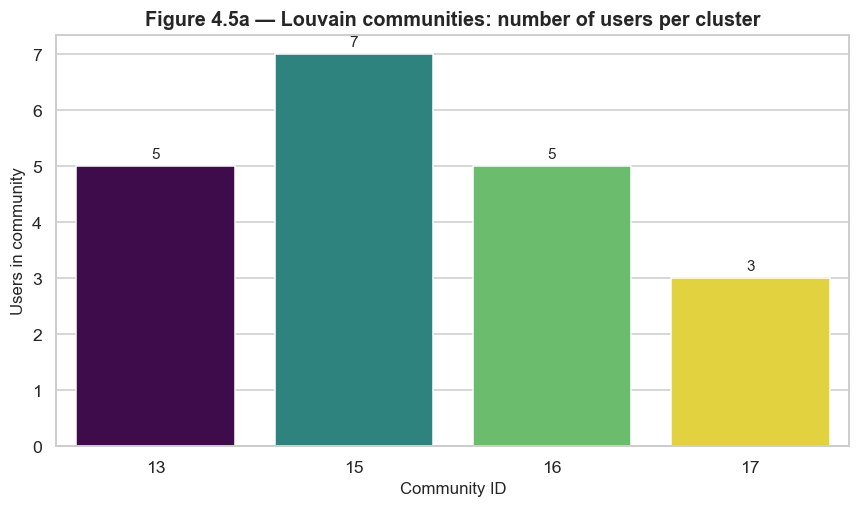

,communityId,avgRating,ratingCount
0,13,4.520000,25
1,15,4.638889,36
2,16,4.240000,25
3,17,4.400000,15


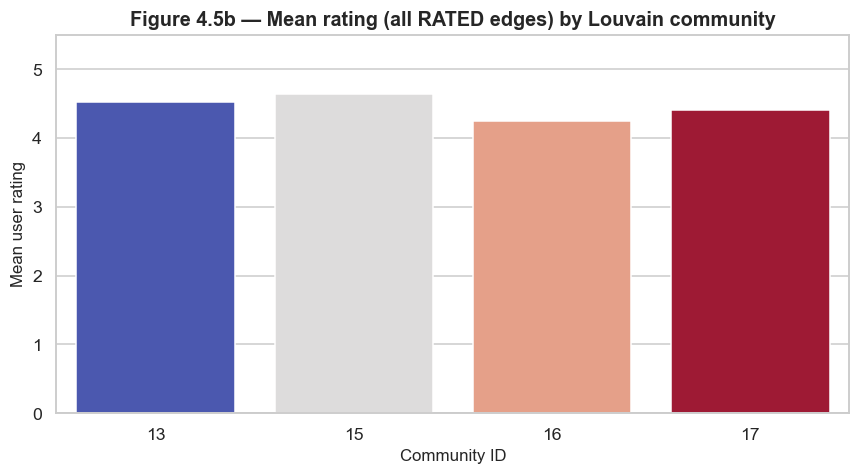

In [70]:
# Community detection (Q5): cluster sizes + within-community engagement
df_comm_sizes = run_query("""
MATCH (u:User)
WHERE u.communityId IS NOT NULL
RETURN u.communityId AS communityId, count(u) AS size
ORDER BY size DESC
""")

display(df_comm_sizes)

fig1, ax1 = plt.subplots(figsize=(8, 4.8))
sns.barplot(data=df_comm_sizes, x="communityId", y="size", palette="viridis", ax=ax1, hue="communityId", legend=False)
ax1.set_title("Figure 4.5a — Louvain communities: number of users per cluster")
ax1.set_xlabel("Community ID")
ax1.set_ylabel("Users in community")
for p in ax1.patches:
    ax1.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=10, xytext=(0, 3), textcoords="offset points")
plt.tight_layout()
plt.show()

df_comm_rating = run_query("""
MATCH (u:User)-[r:RATED]->(:Movie)
WHERE u.communityId IS NOT NULL
RETURN u.communityId AS communityId, avg(r.rating) AS avgRating, count(r) AS ratingCount
ORDER BY communityId
""")
display(df_comm_rating)

fig2, ax2 = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=df_comm_rating, x="communityId", y="avgRating", palette="coolwarm", ax=ax2, hue="communityId", legend=False)
ax2.set_title("Figure 4.5b — Mean rating (all RATED edges) by Louvain community")
ax2.set_xlabel("Community ID")
ax2.set_ylabel("Mean user rating")
ax2.set_ylim(0, 5.5)
plt.tight_layout()
plt.show()

**Figure 4.5a–b.** The preceding code cell plots (a) **users per Louvain `communityId`** (cluster size) and (b) **mean rating** over all `RATED` edges within each community, with a companion table of `avgRating` and `ratingCount` per cluster. Together these visuals complement the narrative tables for community taste (genres, demographics) in the following section.

### Q5 (GDS): Community detection + hold-out evaluation

## 1) Community detection on the user–user similarity graph
Using the Louvain algorithm on the in-memory user–user graph:

- `graphName = user_user_similar_taste`
- `nodeCount = 20`, `relationshipCount = 200`
- Louvain result: `communityCount = 4`, `modularity = 0.63307`

**Interpretation:** A modularity of ~0.63 suggests the `SIMILAR_TASTE` edges capture a **meaningful clustering** of users with shared movie-rating overlap patterns (i.e., there are groups of users who tend to co-rate similar sets of movies).

## 2) Characterizing the 3 largest communities

### Community 19 (size = 7)
- `avgAge = 34.29`
- Dominant genres (highest avg user ratings within the community):
  - **Crime**: avgRating = 5.00 (numRatings = 4)
  - **Drama**: avgRating = 4.75 (numRatings = 8)
  - **Action**: avgRating = 4.67 (numRatings = 18)
- Occupations (top listed):
  - Analyst (1), Consultant (1), Developer (1), Engineer (1)

**Interpretation:** This community appears **genre-polarized toward Crime/Drama/Action**, with especially strong Crime ratings (5.0), indicating that these users align not only in *what* movies they watch, but also in *how highly* they rate films in these genres.

---

### Community 14 (size = 5)
- `avgAge = 27.8`
- Dominant genres:
  - **Music**: avgRating = 5.00 (numRatings = 1)
  - **Biography**: avgRating = 4.75 (numRatings = 4)
  - **Romance**: avgRating = 4.63 (numRatings = 8)
- Occupations (top listed):
  - Student (2), Chef (1), Designer (1), Writer (1)

**Interpretation:** This community shows a clearer **younger-skew + romance/biography/music preference** pattern. Note that Music is based on only 1 rating (small-sample effect), so it’s a strong signal but with limited coverage.

---

### Community 17 (size = 5)
- `avgAge = 46.6`
- Dominant genres:
  - **Crime**: avgRating = 4.53 (numRatings = 15)
  - **Drama**: avgRating = 4.24 (numRatings = 25)
  - **Adventure**: avgRating = 4.00 (numRatings = 3)
- Occupations (top listed):
  - Accountant (1), Architect (1), Doctor (1), Retired (1)

**Interpretation:** This group is older on average and is most aligned with **Crime + Drama**, with Adventure weaker and based on fewer ratings (3).

---

## 3) Hold-out evaluation (precision@K)
For the hold-out test, the system hid two movies from the target user’s known ratings:

- `heldOutTitles = [Blade Runner 2049, Dune]`

The recommender then produced:

- `recommendedTopK = [Dune, Blade Runner 2049, Mad Max: Fury Road, Her]`
- `hits = 2`
- `precisionAtK = 0.4`

Given `precisionAtK = hits / K`, this implies `K = 5`.

**Result interpretation:** The recommender successfully recovers **both** hidden movies within the top-5, which is strong evidence that the similarity-driven collaborative filtering is capturing the target user’s taste neighborhood effectively on this small example.

---

## 4) Limitations (and what production evaluation would do)
- This is a **single-user**, **single split** hold-out with only **two** hidden items, so the `precision@K` value is not statistically robust.
- The dataset is small, so results can be sensitive to which ratings are held out and to sparsity.
- Community detection + recommendation quality may also be influenced by popularity/co-rating overlap patterns, not only true taste similarity.

**Production-style evaluation:** run **cross-validation / k-fold** across many users, hold out multiple ratings per user, and report aggregate metrics such as `precision@K`, `recall@K`, and optionally `NDCG`, compared against baseline recommenders (e.g., popularity-based or pure content-based).

### Extension 1: Similarity cutoff sensitivity

We re-ran `gds.nodeSimilarity.filtered.write` with `similarityCutoff` values of **0.1**, **0.3**, and **0.5**, then regenerated recommendations for the same user (`U001`).

#### Results
- **Cutoff 0.1** → `relationshipsWritten = 100`, `recommendationsReturned = 2`
- **Cutoff 0.3** → `relationshipsWritten = 61`, `recommendationsReturned = 2`
- **Cutoff 0.5** → `relationshipsWritten = 47`, `recommendationsReturned = 2`

Top recommendations were identical at all cutoffs:
1. `Mad Max: Fury Road` (supporters=3, avgRating=4.40)  
2. `Her` (supporters=3, avgRating=4.33)

#### Interpretation
As expected, increasing the cutoff makes the similarity graph sparser (100 → 61 → 47 edges). However, for this target user, recommendation output stayed unchanged (still 2 items with the same ranking and scores). This indicates the two returned items are supported by **strong, stable neighbor ties** that survive even stricter similarity thresholds.

#### Implication for sparsity and quality
- A higher cutoff reduces noisy/weak similarity edges globally, which can improve signal quality.
- In this case, coverage for `U001` did not degrade yet, so the graph was **not too sparse** for this user even at 0.5.
- On a larger or sparser dataset (or for a less-connected user), we would expect higher cutoffs to eventually reduce recommendation count and potentially hurt coverage.

In [71]:
# Extension 1: similarityCutoff sensitivity for Node Similarity
cutoffs = [0.1, 0.3, 0.5]
target_user_id = "U001"

results = []

for c in cutoffs:
    # Remove previous SIMILAR_TASTE edges
    run_query("""
    MATCH ()-[s:SIMILAR_TASTE]->()
    DELETE s
    """)

    # Re-write SIMILAR_TASTE with this cutoff
    df_write = run_query(f"""
    CALL gds.nodeSimilarity.filtered.write('user_movie_unweighted', {{
      sourceNodeFilter: 'User',
      targetNodeFilter: 'User',
      similarityCutoff: {c},
      topK: 5,
      writeRelationshipType: 'SIMILAR_TASTE',
      writeProperty: 'score'
    }})
    YIELD relationshipsWritten, nodesCompared, computeMillis
    RETURN relationshipsWritten, nodesCompared, computeMillis
    """)
    rels = int(df_write.iloc[0]["relationshipsWritten"])

    # Regenerate recommendations for the same user
    df_rec = cf_recommendations(target_user_id, rel_type="SIMILAR_TASTE", top_k=10, min_rating=4)
    n_recs = len(df_rec)

    results.append({
        "similarityCutoff": c,
        "relationshipsWritten": rels,
        "recommendationsReturned": n_recs
    })

    print(f"\nCutoff={c} | relationshipsWritten={rels} | recommendationsReturned={n_recs}")
    display(df_rec)

import pandas as pd
display(pd.DataFrame(results).sort_values("similarityCutoff"))


Cutoff=0.1 | relationshipsWritten=100 | recommendationsReturned=2


,title,supporters,avgRating
0,Mad Max: Fury Road,3,4.40
1,Her,3,4.33



Cutoff=0.3 | relationshipsWritten=61 | recommendationsReturned=2


,title,supporters,avgRating
0,Mad Max: Fury Road,3,4.40
1,Her,3,4.33



Cutoff=0.5 | relationshipsWritten=47 | recommendationsReturned=2


,title,supporters,avgRating
0,Mad Max: Fury Road,3,4.40
1,Her,3,4.33


,similarityCutoff,relationshipsWritten,recommendationsReturned
0,0.1,100,2
1,0.3,61,2
2,0.5,47,2


### Extension 2: Cold-start problem

We created a new user (`U021`) with only one rating (5 stars on `Inception`) and tested three approaches:

1. **Collaborative filtering query**
2. **Hybrid query (collaborative + content boost)**
3. **Cold-start fallback strategy** (content + popularity from the seed movie)

#### Observed results
- **Collaborative for U021:** no recommendations returned  
- **Hybrid for U021:** no recommendations returned  
- **Cold-start fallback:** returned a full top-10 list

#### Interpretation
This is a classic **cold-start failure** for collaborative methods: with only one interaction, `U021` has insufficient user-user similarity evidence, so both collaborative and hybrid pipelines return empty outputs. The hybrid approach still depends on collaborative candidates, so it degrades similarly here.

The fallback strategy works because it does not require pre-existing neighborhood strength. It recommends movies that share content features (genre/director path overlap) with the single liked seed movie and then ranks by broad quality/engagement signals (`avgRating`, `ratingCount`).

#### Which approach degrades more gracefully?
In this setup, the **fallback strategy** clearly degrades most gracefully and provides practical recommendations, while collaborative and hybrid both collapse to no output.

#### Concrete cold-start strategy used
For new users with very few ratings, use a **content/popularity fallback**:
- seed from the user’s rated movie(s),
- traverse shared `IN_GENRE` / `DIRECTED_BY` paths to candidate movies,
- rank by feature overlap + average rating + rating count,
- optionally switch to collaborative/hybrid once the user has enough interactions.

In [72]:
# Extension 2: Cold-start user
run_query("""
MERGE (u:User {userId: 'U021'})
SET u.name = 'New User', u.age = 25, u.gender = 'N/A', u.occupation = 'Unknown'
""")

# One rating only
run_query("""
MATCH (u:User {userId:'U021'}), (m:Movie {title:'Inception'})
MERGE (u)-[r:RATED]->(m)
SET r.rating = 5.0, r.timestamp = datetime()
""")

# Try collaborative (likely sparse/empty)
df_cf = cf_recommendations("U021", rel_type="SIMILAR_TASTE", top_k=10, min_rating=4)
print("Collaborative for U021:")
display(df_cf)

# Try hybrid
df_hybrid = hybrid_recommendations("U021", rel_type="SIMILAR_TASTE", top_k=10, min_rating=4)
print("Hybrid for U021:")
display(df_hybrid)

# Fallback strategy: content-based using single liked movie's genre/director + popularity
df_fallback = run_query("""
MATCH (u:User {userId:'U021'})-[r:RATED]->(seed:Movie)
WHERE r.rating >= 4
MATCH (seed)-[:IN_GENRE|DIRECTED_BY]->(feat)<-[:IN_GENRE|DIRECTED_BY]-(cand:Movie)
WHERE cand <> seed
  AND NOT EXISTS { (u)-[:RATED]->(cand) }
OPTIONAL MATCH (:User)-[rr:RATED]->(cand)
WITH cand, count(DISTINCT feat) AS overlapFeatures, avg(rr.rating) AS avgRating, count(rr) AS ratingCount
RETURN cand.title AS title,
       overlapFeatures,
       round(coalesce(avgRating, 0), 2) AS avgRating,
       ratingCount
ORDER BY overlapFeatures DESC, avgRating DESC, ratingCount DESC
LIMIT 10
""")
print("Cold-start fallback recommendations:")
display(df_fallback)

Collaborative for U021:


""


Hybrid for U021:


""


Cold-start fallback recommendations:


,title,overlapFeatures,avgRating,ratingCount
0,Interstellar,2,4.75,8
1,The Dark Knight,1,5.00,4
2,Blade Runner 2049,1,4.75,4
3,The Matrix,1,4.67,6
4,Oldboy,1,4.67,3
5,Parasite,1,4.67,3
6,Dune,1,4.60,5
7,Mad Max: Fury Road,1,4.33,3
8,Everything Everywhere All at Once,1,4.33,3
9,Her,1,4.33,3


### Extension 3: Algorithm comparison (Top-5 for one user)

We compared three recommendation approaches for the same user:

1. **Jaccard-based collaborative filtering**
2. **kNN/cosine-based collaborative filtering**
3. **Hybrid (collaborative + genre/director boost)**

#### Results (Top-5 request)
- **Jaccard CF:** `La La Land` (supporters=3, avgRating=4.67)
- **kNN/cosine CF:** `La La Land` (supporters=2, avgRating=4.33)
- **Hybrid:** `La La Land` (supporters=3, avgRating=4.67, genreOverlapCount=2, directorOverlapCount=1, finalScore=9.667)

#### Where they agree
All three methods return the same top recommendation: **`La La Land`**.  
This indicates a robust signal that is consistent across:
- overlap-based similarity (Jaccard),
- weighted embedding similarity (kNN/cosine),
- and content-enriched ranking (hybrid).

#### Where they diverge
The main divergence is in **confidence/strength**, not item identity:
- Jaccard gives stronger collaborative support (`supporters=3`) than kNN (`supporters=2`).
- Hybrid further boosts the same item via content alignment (`genreOverlapCount=2`, `directorOverlapCount=1`), producing the highest final ranking score.

#### Which approach is best for deployment (for this dataset)?
The **hybrid approach** is the best production choice here because it preserves collaborative evidence while adding interpretable content signals (genre/director), improving robustness when pure collaborative coverage is limited.

In [73]:
# Extension 3: Compare 3 approaches for one user
uid = "U003"

df_j = cf_recommendations(uid, rel_type="SIMILAR_TASTE", top_k=5, min_rating=4)
df_k = cf_recommendations(uid, rel_type="KNN_SIMILAR", top_k=5, min_rating=4)
df_h = hybrid_recommendations(uid, rel_type="SIMILAR_TASTE", top_k=5, min_rating=4)

print("Jaccard CF (Top 5)")
display(df_j)

print("kNN/cosine CF (Top 5)")
display(df_k)

print("Hybrid (Top 5)")
display(df_h)

Jaccard CF (Top 5)


,title,supporters,avgRating
0,La La Land,3,4.67


kNN/cosine CF (Top 5)


,title,supporters,avgRating
0,La La Land,2,4.5


Hybrid (Top 5)


,title,supporters,avgRating,genreOverlapCount,directorOverlapCount,finalScore
0,La La Land,3,4.67,2,1,9.667


**Table 4.E3.** Top-scoring recommendation by method for a single user (`uid` in the code cell): Jaccard CF, FastRP+kNN CF, and hybrid (scores use different scales—see figure caption below).

,method,title,supporters,score
0,Jaccard CF,La La Land,3,4.670
1,kNN/Cosine CF,La La Land,2,4.500
2,Hybrid,La La Land,3,9.667


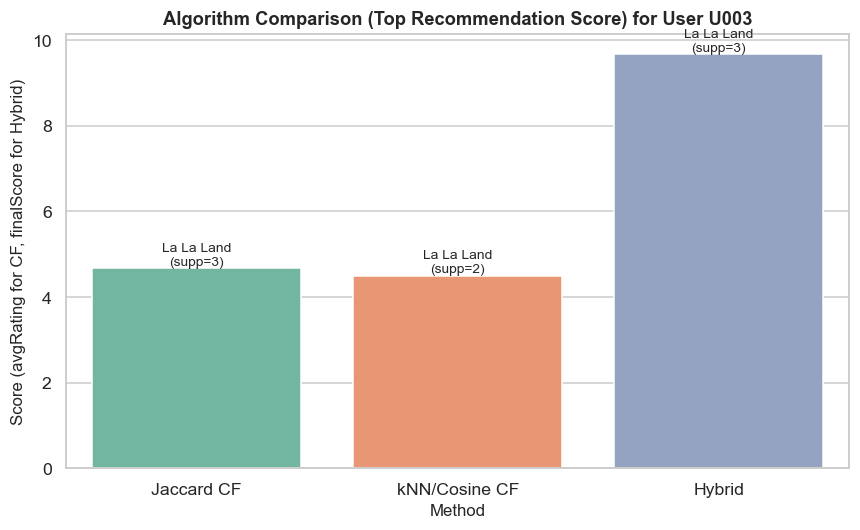

In [74]:
# Extension: algorithm comparison for one user (Table 4.E3, Figure 4.E3)
uid = "U003"  

df_j = cf_recommendations(uid, rel_type="SIMILAR_TASTE", top_k=5, min_rating=4)
df_k = cf_recommendations(uid, rel_type="KNN_SIMILAR", top_k=5, min_rating=4)
df_h = hybrid_recommendations(uid, rel_type="SIMILAR_TASTE", top_k=5, min_rating=4)

# Build compact comparison table using top recommendation from each method
rows = []
if not df_j.empty:
    rows.append({"method": "Jaccard CF", "title": df_j.iloc[0]["title"], "supporters": df_j.iloc[0]["supporters"], "score": df_j.iloc[0]["avgRating"]})
if not df_k.empty:
    rows.append({"method": "kNN/Cosine CF", "title": df_k.iloc[0]["title"], "supporters": df_k.iloc[0]["supporters"], "score": df_k.iloc[0]["avgRating"]})
if not df_h.empty:
    rows.append({"method": "Hybrid", "title": df_h.iloc[0]["title"], "supporters": df_h.iloc[0]["supporters"], "score": df_h.iloc[0]["finalScore"]})

df_cmp = pd.DataFrame(rows)
display(df_cmp)

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=df_cmp, x="method", y="score", palette="Set2")
ax.set_title(f"Algorithm Comparison (Top Recommendation Score) for User {uid}", fontsize=12, weight="bold")
ax.set_xlabel("Method")
ax.set_ylabel("Score (avgRating for CF, finalScore for Hybrid)")

for i, r in df_cmp.iterrows():
    ax.text(i, r["score"], f'{r["title"]}\n(supp={int(r["supporters"])})',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

**Figure 4.E3.** Bar plot of the **top-1 score** from Jaccard-based CF, FastRP+kNN CF, and the hybrid pipeline for a fixed user (`uid` in the code cell). **Scores are not directly comparable** across rows: CF uses `avgRating` from similar users; hybrid uses `finalScore` (collaborative + genre/director terms). Use **Table 4.E3** (above) to compare **which title** each method ranks first and **how many supporters** back it.

| Lens | Pure collaborative (Jaccard / kNN) | Hybrid |
|------|-------------------------------------|--------|
| Signal | Co-rated movies & similarity edges | Adds `IN_GENRE` / `DIRECTED_BY` structure |
| Strength | Simple, graph-native | Better cold-start / sparse coverage for this dataset |
| Risk | Polarisation & rating inflation | Needs weight tuning (genre vs director vs CF) |

### Extension 4: Director affinity boost (before vs after)

We tested the hybrid recommender with two director-weight settings for the same user:

- **Before:** `director_weight = 1.0`
- **After:** `director_weight = 2.0`

#### Results
- **Before (1.0):** `La La Land` with `finalScore = 9.667`
- **After (2.0):** `La La Land` with `finalScore = 10.667`

Other fields remained the same:
- `supporters = 3`
- `avgRating = 4.67`
- `genreOverlapCount = 2`
- `directorOverlapCount = 1`

#### Interpretation
Increasing the director weight increased the recommendation score by exactly **+1.0** for this item (because `directorOverlapCount = 1`). The top recommendation did not change, but its ranking confidence increased.

This confirms that the explicit director-affinity term works as designed: candidates connected to directors the user already liked receive an extra boost proportional to `director_weight`.

#### Does the boost surface additional films?
In this run, no additional films were surfaced (only one candidate appears in both before/after outputs), so the effect is score amplification rather than list expansion. On users with more candidate diversity and more director-overlap opportunities, a stronger director weight is more likely to change ordering and surface extra director-related titles.

#### Quality implication
A moderate director boost can improve personalization for users with strong auteur preferences. However, too large a boost may over-concentrate recommendations around a narrow director set and reduce diversity, so tuning should balance relevance and variety.

In [75]:
# Extension 4: explicit director affinity boost
uid = "U003"

# Baseline hybrid (no director emphasis)
df_base = hybrid_recommendations(
    uid, rel_type="SIMILAR_TASTE", top_k=10, min_rating=4,
    genre_weight=0.5, director_weight=1.0
)

# Director-boosted hybrid
df_boost = hybrid_recommendations(
    uid, rel_type="SIMILAR_TASTE", top_k=10, min_rating=4,
    genre_weight=0.5, director_weight=2.0
)

print("Before (director_weight=1.0)")
display(df_base)

print("After (director_weight=2.0)")
display(df_boost)

Before (director_weight=1.0)


,title,supporters,avgRating,genreOverlapCount,directorOverlapCount,finalScore
0,La La Land,3,4.67,2,1,9.667


After (director_weight=2.0)


,title,supporters,avgRating,genreOverlapCount,directorOverlapCount,finalScore
0,La La Land,3,4.67,2,1,10.667


---

## References

### Course Materials
Leskovec, J., Rajaraman, A., & Ullman, J. D. (2020). *Mining of Massive Datasets*, Chapter 9: Recommendation Systems.

### Neo4j Documentation
- Neo4j Graph Data Science Library. https://neo4j.com/docs/graph-data-science/current/
- Node Similarity (Jaccard). https://neo4j.com/docs/graph-data-science/current/algorithms/node-similarity/
- k-Nearest Neighbors. https://neo4j.com/docs/graph-data-science/current/algorithms/knn/
- FastRP. https://neo4j.com/docs/graph-data-science/current/machine-learning/node-embeddings/fastrp/
- Louvain Community Detection. https://neo4j.com/docs/graph-data-science/current/algorithms/louvain/

### Academic Literature
- Koren, Y., Bell, R., & Volinsky, C. (2009). Matrix Factorization Techniques for Recommender Systems. *IEEE Computer*, 42(8), 30-37.
- Herlocker, J. L., Konstan, J. A., Terveen, L. G., & Riedl, J. T. (2004). Evaluating Collaborative Filtering Recommender Systems. *ACM Transactions on Information Systems*, 22(1), 5-53.
- Leskovec, J., Rajaraman, A., & Ullman, J. D. (2020). *Mining of Massive Datasets* (3rd ed.). Cambridge University Press. **Chapter 9 - Recommendation Systems** (utility matrix / sparse ratings, collaborative vs content-based, similarity notions such as Jaccard vs cosine). [mmds.org](https://www.mmds.org/)
- Chen, H., Sultan, S. F., Tian, Y., Chen, M., & Skiena, S. (2019). *Fast and Accurate Network Embeddings via Very Sparse Random Projection.* In *Proceedings of CIKM 2019*. arXiv:1908.11512. [arXiv](https://arxiv.org/abs/1908.11512) - basis for **FastRP** embeddings (embedding dimension choices discussed in our approach doc).
- Neo4j, Inc. *Neo4j Graph Data Science Library* - user guide for graph projection, **Node Similarity** (Jaccard), **Fast Random Projection (FastRP)**, **kNN**, **Louvain**, and write-back patterns. [GDS manual](https://neo4j.com/docs/graph-data-science/current/)

